# Commodity Futures Trading Strategy Development - Starter Notebook

This notebook provides basic data loading functionality to help you get started with the assessment.

## Important Notes
- Focus on methodology over pure performance
- Document your assumptions and approach
- Feel free to modify this notebook or create your own from scratch
- All data is synthetically generated and has no relation to actual market prices


In [1]:
%matplotlib inline
import os
os.environ['PY3_PROD'] = '1'
%load_ext autoreload
%autoreload 2
os.system('kinit')

1

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import warnings
warnings.filterwarnings('ignore')
import re
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Data

Load all the provided datasets. Adjust the path if you're running this from a different directory.


In [3]:
# Define data directory
DATA_DIR = './data/'

# Load main datasets
print("Loading price data...")
price_data = pd.read_csv(DATA_DIR + 'price_data.csv')
price_data['date'] = pd.to_datetime(price_data['date'])
print(f"Price data shape: {price_data.shape}")

print("\nLoading commodity information...")
commodity_info = pd.read_csv(DATA_DIR + 'commodity_info.csv')
print(f"Commodity info shape: {commodity_info.shape}")

print("\nLoading sector information...")
sector_info = pd.read_csv(DATA_DIR + 'sector_info.csv')
print(f"Sector info shape: {sector_info.shape}")

print("\nLoading FX data...")
fx_data = pd.read_csv(DATA_DIR + 'fx_data.csv')
fx_data['date'] = pd.to_datetime(fx_data['date'])
print(f"FX data shape: {fx_data.shape}")

# Load alternative data - economic indicators
print("\nLoading economic data...")
try:
    economic_weekly = pd.read_csv(DATA_DIR + 'economic_weekly.csv')
    economic_weekly['date'] = pd.to_datetime(economic_weekly['date'])
    print(f"Economic weekly shape: {economic_weekly.shape}")
    
    economic_monthly = pd.read_csv(DATA_DIR + 'economic_monthly.csv')
    economic_monthly['date'] = pd.to_datetime(economic_monthly['date'])
    print(f"Economic monthly shape: {economic_monthly.shape}")
except:
    print("Some economic data files not found")

# Load other alternative data
print("\nLoading other alternative data...")
alt_data_files = [
    'economic_weekly', 'economic_monthly', 'fx_data',
    'weather_weekly', 'supply_chain_weekly', 'geopolitical_weekly',
    'sentiment_daily', 'shipping_weekly', 'energy_weekly',
    'agricultural_weekly', 'industrial_weekly', 'financial_daily'
]

alt_data = {}
df_list = []
for file_name in alt_data_files:
    try:
        df = pd.read_csv(DATA_DIR + file_name + '.csv')
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
        alt_data[file_name] = df
        df_list.append(df)
    except:
        print(f"  {file_name}: not found")

spot_df = pd.concat(df_list, axis=1)


Loading price data...
Price data shape: (584647, 5)

Loading commodity information...
Commodity info shape: (59, 11)

Loading sector information...
Sector info shape: (7, 2)

Loading FX data...
FX data shape: (2023, 2)

Loading economic data...
Economic weekly shape: (404, 20)
Economic monthly shape: (94, 23)

Loading other alternative data...


## 2. Basic Data Exploration

Here are some helper functions and initial explorations to get you started.


In [4]:
# Display basic information about commodities
print("Commodity Information Summary:")
print("-" * 50)
print(f"Total commodities: {commodity_info.shape[0]}")
print(f"US commodities: {(commodity_info['market'] == 'US').sum()}")
print(f"China commodities: {(commodity_info['market'] == 'CN').sum()}")
print(f"\nNumber of sectors: {commodity_info['sector'].nunique()}")
print(f"\nSectors:")
print(commodity_info['sector'].value_counts())
print(f"\nExpiry schemes:")
print(commodity_info['expiry_scheme'].value_counts())

# Display first few rows
commodity_info.head()


Commodity Information Summary:
--------------------------------------------------
Total commodities: 59
US commodities: 20
China commodities: 39

Number of sectors: 7

Sectors:
sector
Agriculture       16
Chemicals         12
BaseMetals         8
Energy             7
PreciousMetals     6
Ferrous            5
Softs              5
Name: count, dtype: int64

Expiry schemes:
expiry_scheme
monthly       29
quarterly     20
bi-annual      5
bi-monthly     5
Name: count, dtype: int64


,commodity,commodity_type,market,currency,sector,expiry_scheme,expiry_day,contract_size,tick_size,transaction_cost_bps,slippage_bps
0,US_Crude,Crude,US,USD,Energy,monthly,15,1000,0.10,1.710126,0.855063
1,CN_Crude,Crude,CN,CNY,Energy,monthly,8,50,0.25,1.378021,0.689011
2,US_Gold,Gold,US,USD,PreciousMetals,monthly,21,100,0.01,2.068521,1.034261
3,CN_Gold,Gold,CN,CNY,PreciousMetals,monthly,28,50,0.25,2.660827,1.330414
4,US_Silver,Silver,US,USD,PreciousMetals,quarterly,9,10,0.10,2.156378,1.078189


In [5]:
# Check available contracts for each commodity
print("Available contracts in the data:")
contracts = price_data['contract'].unique()
print(f"Contract types: {sorted(contracts)}")

# Check date range
print(f"\nDate range: {price_data['date'].min()} to {price_data['date'].max()}")
print(f"Number of trading days: {price_data['date'].nunique()}")


Available contracts in the data:
Contract types: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'SPOT']

Date range: 2018-01-01 00:00:00 to 2025-10-01 00:00:00
Number of trading days: 2023


## 3. Data Access Functions

Basic functions to help you load specific commodity data.


In [6]:
def get_commodity_data(commodity_name, contract='F1'):
    """
    Get price data for a specific commodity and contract.
    
    Parameters:
    -----------
    commodity_name : str
        The commodity name (e.g., 'US_Crude', 'CN_Gold')
    contract : str
        The contract type (e.g., 'SPOT', 'F1', 'F2', etc.)
    
    Returns:
    --------
    DataFrame with date, price, and volume
    """
    mask = (price_data['commodity'] == commodity_name) & (price_data['contract'] == contract)
    return price_data[mask][['date', 'price', 'volume']].sort_values('date').reset_index(drop=True)


def get_all_commodities():
    """
    Get list of all available commodities.
    
    Returns:
    --------
    List of commodity names
    """
    return price_data['commodity'].unique().tolist()


def get_contracts_for_commodity(commodity_name):
    """
    Get all available contracts for a specific commodity.
    
    Parameters:
    -----------
    commodity_name : str
        The commodity name
    
    Returns:
    --------
    List of contract names
    """
    return price_data[price_data['commodity'] == commodity_name]['contract'].unique().tolist()

print("Data access functions loaded successfully!")


Data access functions loaded successfully!


## 4. Example: Plotting a Commodity Price Series

Here's a simple example of how to visualize commodity data.


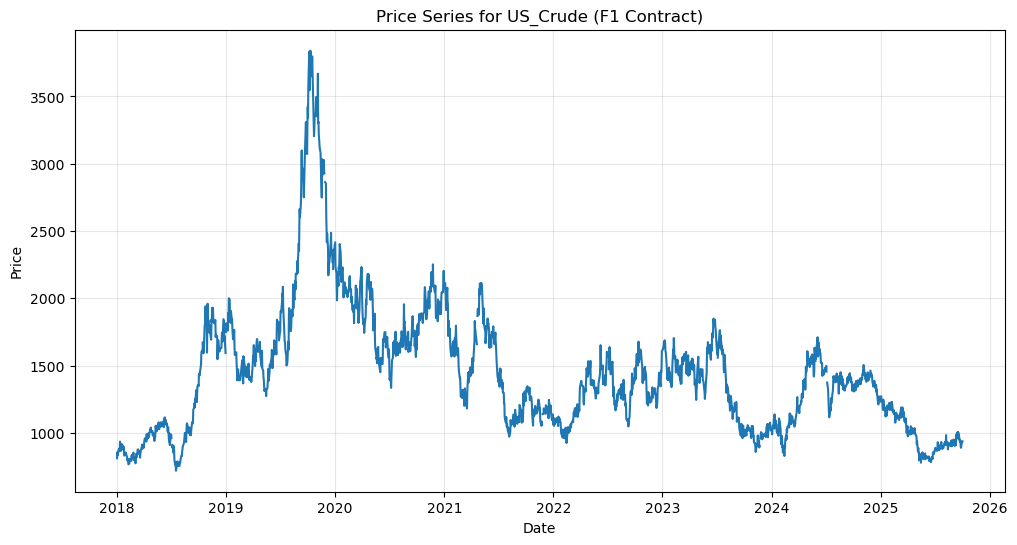

Missing data: 1.48%


In [7]:
# Example: Plot price series for US Crude
example_commodity = 'US_Crude'
example_data = get_commodity_data(example_commodity, 'F1')

if not example_data.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(example_data['date'], example_data['price'])
    plt.title(f"Price Series for {example_commodity} (F1 Contract)")
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Check for missing data
    missing_pct = example_data['price'].isna().sum() / len(example_data) * 100
    print(f"Missing data: {missing_pct:.2f}%")
else:
    print(f"No data found for {example_commodity}")


## 5. Analytics

In [8]:
px_pivot = pd.pivot_table(price_data, index='date', columns=['commodity', 'contract'], values='price', aggfunc='last')
volume_pivot = pd.pivot_table(price_data, index='date', columns=['commodity', 'contract'], values='volume', aggfunc='last')

# px_pivot.columns.get_level_values(0).unique()

us_assets = [ asset for asset in px_pivot.columns.get_level_values(0).unique() if asset[:2] == "US"]

cn_assets = [ asset for asset in px_pivot.columns.get_level_values(0).unique() if asset[:2] == "CN"]

cn_index = px_pivot.loc[:, px_pivot.columns.get_level_values(0).isin(cn_assets) & px_pivot.columns.get_level_values(1).isin(["F1"])].dropna(how='all').index
us_index = px_pivot.loc[:, px_pivot.columns.get_level_values(0).isin(us_assets) & px_pivot.columns.get_level_values(1).isin(["F1"])].dropna(how='all').index


contract rolling, based on expiry time and roll the contract roll_day before the expiry.
In reality, need to consider the liquidity and also potential index roll period.
But this data, the future curve correlation is almost 1, so don't expect performance impact from the roll

In [9]:
def build_roll_adj_px(df, expiry_dates, roll_day=0, mode='ret', contract=1):
    curr_cont = f"F{contract}"
    next_cont = f"F{contract+1}"
    df = df.sort_index()
    index = df.index
    if mode == 'ret':
        df = np.log(df)
    expiry_dates = pd.to_datetime(expiry_dates)
    aligned_expiry, aligned_roll = [], []
    for ed in expiry_dates:
        if ed < index[0]:
            continue
        elif ed > index[-1]:
            ed_aligned = ed
        else:
            ed_aligned = index[index <= ed].max()
        rd_nominal = ed_aligned - pd.tseries.offsets.BDay(roll_day)
        if rd_nominal > index[-1]:
            continue
        elif rd_nominal < index[0]:
            rd_aligned = rd_nominal
        else:
            rd_aligned = index[index <= rd_nominal].max()
        aligned_expiry.append(ed_aligned)
        aligned_roll.append(rd_aligned)
    if not aligned_expiry:
        raise ValueError("No expiry dates fall within the data index range")

    roll_diffs = []
    for rd in aligned_roll:
        if rd in df.index:
            diff = df.loc[rd, curr_cont] - df.loc[rd, next_cont]
            roll_diffs.append((rd, diff))
        else:
            roll_diffs.append((rd, 0))

    roll_df = pd.DataFrame(roll_diffs, columns=['roll_date', 'diff']).set_index('roll_date')
    adj_series_daily = roll_df['diff'].reindex(index=index, fill_value=0).shift(1).fillna(0).cumsum()

    unadj = df[curr_cont].copy()

    if roll_day > 0:
        for ed, rd in zip(aligned_expiry, aligned_roll):
            mask = (index > rd) & (index <= ed)
            unadj.loc[mask] += df.loc[mask, next_cont] - df.loc[mask, curr_cont]

    ts = unadj + adj_series_daily
    if mode == 'ret':
        ts = np.exp(ts)
        unadj = np.exp(unadj)
        adj_series_daily = np.exp(adj_series_daily)
    ts.name = curr_cont
    # debug = {"cont": unadj, 
    #          "adj": adj_series_daily,
    #          "roll_df": roll_df}
    return ts



fixing the missing data for F1, F2, F3 data using the ratio, remove the problematic spot data

In [10]:
px_dict = {}
for asset in us_assets + cn_assets:
    ratio_f1 = px_pivot[(asset, "F1")]/px_pivot[(asset, "F1")].shift()
    ratio_f2 = px_pivot[(asset, "F2")]/px_pivot[(asset, "F2")].shift()
    ratio_f3 = px_pivot[(asset, "F3")]/px_pivot[(asset, "F3")].shift()

    mask1 = px_pivot[(asset, "F1")].isna() & (~ px_pivot[(asset, "F2")].isna()) & (~ px_pivot[(asset, "F2")].shift().isna()) & (~px_pivot[(asset, "F1")].shift().isna())
    px_pivot.loc[mask1, (asset, "F1")] = px_pivot[(asset, "F1")].shift()[mask1] * ratio_f2[mask1]

    mask2 = px_pivot[(asset, "F1")].isna() & (~ px_pivot[(asset, "F3")].isna()) & (~ px_pivot[(asset, "F3")].shift().isna()) & (~px_pivot[(asset, "F1")].shift().isna())
    px_pivot.loc[mask2, (asset, "F1")] = px_pivot[(asset, "F1")].shift()[mask2] * ratio_f3[mask2]

    mask3 = px_pivot[(asset, "F2")].isna() & (~ px_pivot[(asset, "F1")].isna()) & (~ px_pivot[(asset, "F1")].shift().isna()) & (~px_pivot[(asset, "F2")].shift().isna())
    px_pivot.loc[mask3, (asset, "F2")] = px_pivot[(asset, "F2")].shift()[mask3] * ratio_f1[mask3]
    
    mask4 = px_pivot[(asset, "F3")].isna() & (~ px_pivot[(asset, "F1")].isna()) & (~ px_pivot[(asset, "F1")].shift().isna()) & (~px_pivot[(asset, "F2")].shift().isna())
    px_pivot.loc[mask4, (asset, "F3")] = px_pivot[(asset, "F3")].shift()[mask4] * ratio_f1[mask4]

    mask3 = abs(px_pivot[(asset, "SPOT")]/px_pivot[(asset, "F1")]-1) > 0.1
    px_pivot.loc[mask3, (asset, "SPOT")] = np.nan

    df = px_pivot.loc[:, px_pivot.columns.get_level_values(0)==asset].droplevel([0], axis=1)
     
    asset_info = commodity_info[commodity_info['commodity'] == asset].to_dict("records")[0]
    if asset_info['expiry_scheme'] == 'monthly':
        mth_list = range(1, 13)
    elif asset_info['expiry_scheme'] == 'quarterly':
        mth_list = [3, 6, 9, 12]
    elif asset_info['expiry_scheme'] == 'bi-annual':
        mth_list = [6, 12]
    elif asset_info['expiry_scheme'] == 'bi-monthly':
        mth_list = [1, 3, 5, 7, 9, 11]
    else:
        mth_list = range(1, 13)
    
    roll_day = 5
    expiry_day = asset_info['expiry_day']
    
    expiry_dates = [ d + pd.DateOffset(days = expiry_day-1) for d in pd.date_range(start=df.index[0], end=df.index[-1] + pd.DateOffset(months=6), freq="MS") 
                    if d.month in mth_list]

    px_dict[asset] = build_roll_adj_px(df, expiry_dates, roll_day=roll_day, mode='ret', contract=1)


In [ ]:
# import pickle
# data_file = "C:/dev/data/optiver_processed.pkl"
# with open(data_file, 'wb') as f:
#     df_dict = {
#         'hist_data': px_pivot,
#         'roll_adj': px_dict,
#     }
#     pickle.dump(df_dict, f)

In [11]:
# sector correlations

sector_assets = {}
for sector in commodity_info['sector'].unique():
    sector_assets[sector] = list(commodity_info[commodity_info['sector']==sector]['commodity'])
    f1_px = px_pivot.loc[:, (px_pivot.columns.get_level_values(0).isin(sector_assets[sector])) & (px_pivot.columns.get_level_values(1)=='F1')].droplevel([1], axis=1)
    f1_px = np.log(f1_px.dropna())
    f1_px = f1_px.diff()
    np.exp(f1_px.cumsum()).plot(title=sector)
    display(f1_px.corr())

commodity,CN_Coal,CN_Crude,US_Crude,US_Ethanol,US_Gasoline,US_HeatingOil,US_NaturalGas
commodity,,,,,,,
CN_Coal,1.000000,0.227663,0.285614,0.244131,0.260115,0.262388,0.196391
CN_Crude,0.227663,1.000000,0.551776,0.533298,0.197311,0.204077,0.161050
US_Crude,0.285614,0.551776,1.000000,0.648739,0.536327,0.475104,0.518372
US_Ethanol,0.244131,0.533298,0.648739,1.000000,0.473546,0.474467,0.549480
US_Gasoline,0.260115,0.197311,0.536327,0.473546,1.000000,0.508341,0.537280
US_HeatingOil,0.262388,0.204077,0.475104,0.474467,0.508341,1.000000,0.504104
US_NaturalGas,0.196391,0.161050,0.518372,0.549480,0.537280,0.504104,1.000000


commodity,CN_Gold,CN_Silver,US_Gold,US_Palladium,US_Platinum,US_Silver
commodity,,,,,,
CN_Gold,1.000000,0.684252,0.172697,0.233060,0.273297,0.274374
CN_Silver,0.684252,1.000000,0.094495,0.227365,0.218320,0.270334
US_Gold,0.172697,0.094495,1.000000,0.259324,0.265259,0.909719
US_Palladium,0.233060,0.227365,0.259324,1.000000,0.674205,0.282758
US_Platinum,0.273297,0.218320,0.265259,0.674205,1.000000,0.285681
US_Silver,0.274374,0.270334,0.909719,0.282758,0.285681,1.000000


commodity,CN_Aluminum,CN_Copper,CN_Lead,CN_Nickel,CN_Tin,CN_Zinc,US_Aluminum,US_Copper
commodity,,,,,,,,
CN_Aluminum,1.000000,0.267948,0.293515,0.183188,0.293346,0.259582,0.303117,0.163564
CN_Copper,0.267948,1.000000,0.255258,0.264046,0.281726,0.305169,0.142165,0.313597
CN_Lead,0.293515,0.255258,1.000000,0.343204,0.312605,0.273841,0.176019,0.137017
CN_Nickel,0.183188,0.264046,0.343204,1.000000,0.245199,0.356322,0.115512,0.250348
CN_Tin,0.293346,0.281726,0.312605,0.245199,1.000000,0.229222,0.100997,0.125047
CN_Zinc,0.259582,0.305169,0.273841,0.356322,0.229222,1.000000,0.140271,0.246109
US_Aluminum,0.303117,0.142165,0.176019,0.115512,0.100997,0.140271,1.000000,0.692422
US_Copper,0.163564,0.313597,0.137017,0.250348,0.125047,0.246109,0.692422,1.000000


commodity,CN_Corn,CN_Cotton,CN_PalmOil,CN_Rapeseed,CN_SoybeanMeal,CN_SoybeanOil,CN_Soybeans,CN_Sugar,US_Cocoa,US_Coffee,US_Corn,US_Cotton,US_Rice,US_Soybeans,US_Sugar,US_Wheat
commodity,,,,,,,,,,,,,,,,
CN_Corn,1.000000,0.273343,0.246039,0.428115,0.314972,0.332501,0.237634,0.314916,0.238842,0.408590,0.425774,0.327267,0.263800,0.297890,0.150093,0.235432
CN_Cotton,0.273343,1.000000,0.165662,0.211743,0.251137,0.249441,0.126056,0.216040,0.216583,0.305156,0.195436,0.411358,0.206881,0.210926,0.239388,0.263930
CN_PalmOil,0.246039,0.165662,1.000000,0.229389,0.189065,0.529078,0.688141,0.491986,0.553416,0.210837,0.517642,0.136294,0.199432,0.109667,0.169576,0.201192
CN_Rapeseed,0.428115,0.211743,0.229389,1.000000,0.218399,0.251499,0.226983,0.278459,0.182855,0.241257,0.192149,0.231150,0.215510,0.256246,0.131539,0.162138
CN_SoybeanMeal,0.314972,0.251137,0.189065,0.218399,1.000000,0.239265,0.258624,0.329729,0.248485,0.257801,0.197914,0.242445,0.334538,0.313134,0.178976,0.219622
CN_SoybeanOil,0.332501,0.249441,0.529078,0.251499,0.239265,1.000000,0.480046,0.411896,0.443602,0.307795,0.485385,0.267293,0.271829,0.243347,0.159053,0.207249
CN_Soybeans,0.237634,0.126056,0.688141,0.226983,0.258624,0.480046,1.000000,0.465993,0.478769,0.198326,0.491793,0.160187,0.159541,0.293880,0.152278,0.174092
CN_Sugar,0.314916,0.216040,0.491986,0.278459,0.329729,0.411896,0.465993,1.000000,0.439138,0.342798,0.448445,0.281326,0.225356,0.278407,0.274337,0.315928
US_Cocoa,0.238842,0.216583,0.553416,0.182855,0.248485,0.443602,0.478769,0.439138,1.000000,0.505292,0.670339,0.442934,0.391643,0.474183,0.568825,0.478390


commodity,CN_HotRolledCoil,CN_IronOre,CN_Rebar,CN_Steel,US_IronOre
commodity,,,,,
CN_HotRolledCoil,1.000000,0.339893,0.443255,0.493955,0.405636
CN_IronOre,0.339893,1.000000,0.343612,0.447814,0.303870
CN_Rebar,0.443255,0.343612,1.000000,0.535164,0.622283
CN_Steel,0.493955,0.447814,0.535164,1.000000,0.372700
US_IronOre,0.405636,0.303870,0.622283,0.372700,1.000000


commodity,CN_Bitumen,CN_Cobalt,CN_DAP,CN_Lithium,CN_MEG,CN_Methanol,CN_PE,CN_PP,CN_PTA,CN_PVC,CN_RareEarth,CN_Urea
commodity,,,,,,,,,,,,
CN_Bitumen,1.000000,0.322759,0.322523,0.383147,0.328662,0.349055,0.403700,0.328351,0.406736,0.212535,0.342426,0.374995
CN_Cobalt,0.322759,1.000000,0.390305,0.180595,0.516592,0.422577,0.432907,0.348663,0.469169,0.323819,0.303426,0.472967
CN_DAP,0.322523,0.390305,1.000000,0.302957,0.433795,0.334125,0.393015,0.315728,0.401441,0.271417,0.380420,0.405669
CN_Lithium,0.383147,0.180595,0.302957,1.000000,0.272247,0.262808,0.281765,0.361026,0.366492,0.467593,0.243794,0.438467
CN_MEG,0.328662,0.516592,0.433795,0.272247,1.000000,0.408858,0.371609,0.377494,0.396221,0.259509,0.301888,0.450793
CN_Methanol,0.349055,0.422577,0.334125,0.262808,0.408858,1.000000,0.404141,0.441767,0.351834,0.331219,0.341356,0.311622
CN_PE,0.403700,0.432907,0.393015,0.281765,0.371609,0.404141,1.000000,0.295789,0.335154,0.254385,0.403925,0.403835
CN_PP,0.328351,0.348663,0.315728,0.361026,0.377494,0.441767,0.295789,1.000000,0.303298,0.330450,0.348190,0.304465
CN_PTA,0.406736,0.469169,0.401441,0.366492,0.396221,0.351834,0.335154,0.303298,1.000000,0.258041,0.293101,0.349096


commodity,CN_Glass,CN_Paper,CN_Pulp,CN_Rubber,CN_SodaAsh
commodity,,,,,
CN_Glass,1.000000,0.325219,0.204579,0.254823,0.353795
CN_Paper,0.325219,1.000000,0.256180,0.318974,0.314011
CN_Pulp,0.204579,0.256180,1.000000,0.314715,0.282199
CN_Rubber,0.254823,0.318974,0.314715,1.000000,0.304582
CN_SodaAsh,0.353795,0.314011,0.282199,0.304582,1.000000


In [12]:
f1_px = px_pivot.loc[:, px_pivot.columns.get_level_values(1)=='F1'].droplevel([1], axis=1)
spot_px = px_pivot.loc[:, px_pivot.columns.get_level_values(1)=='SPOT'].droplevel([1], axis=1)

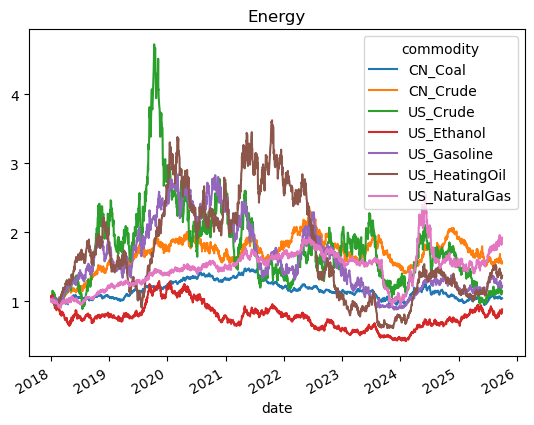

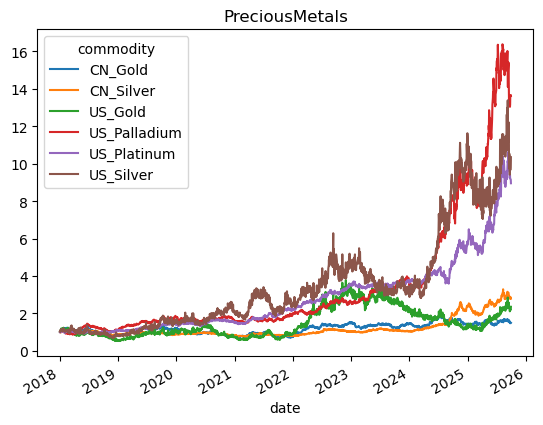

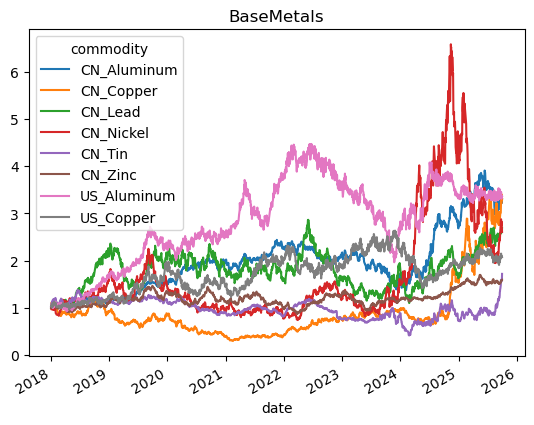

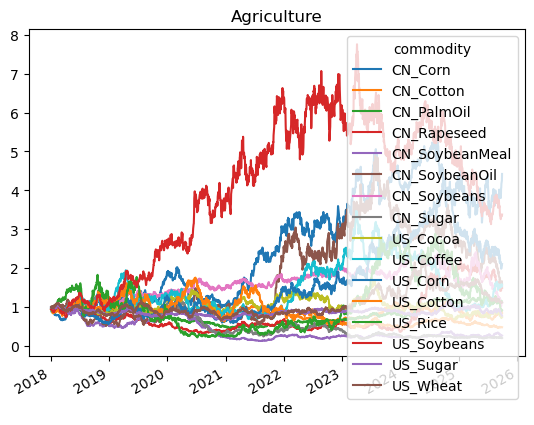

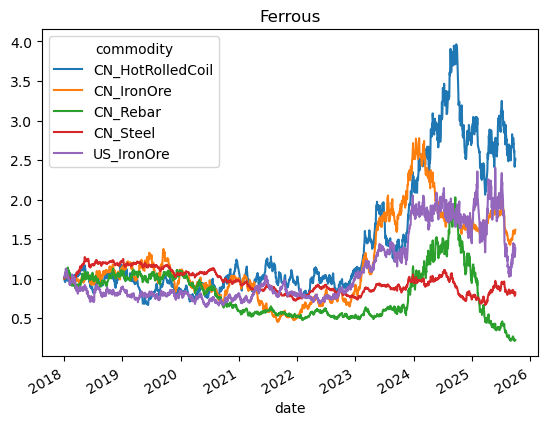

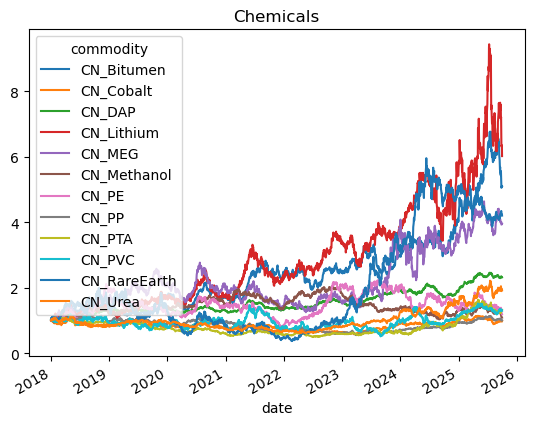

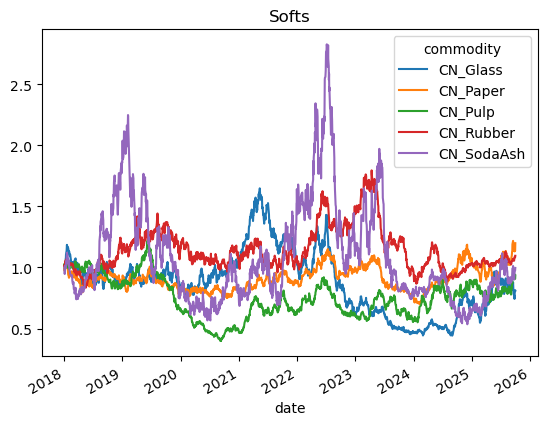

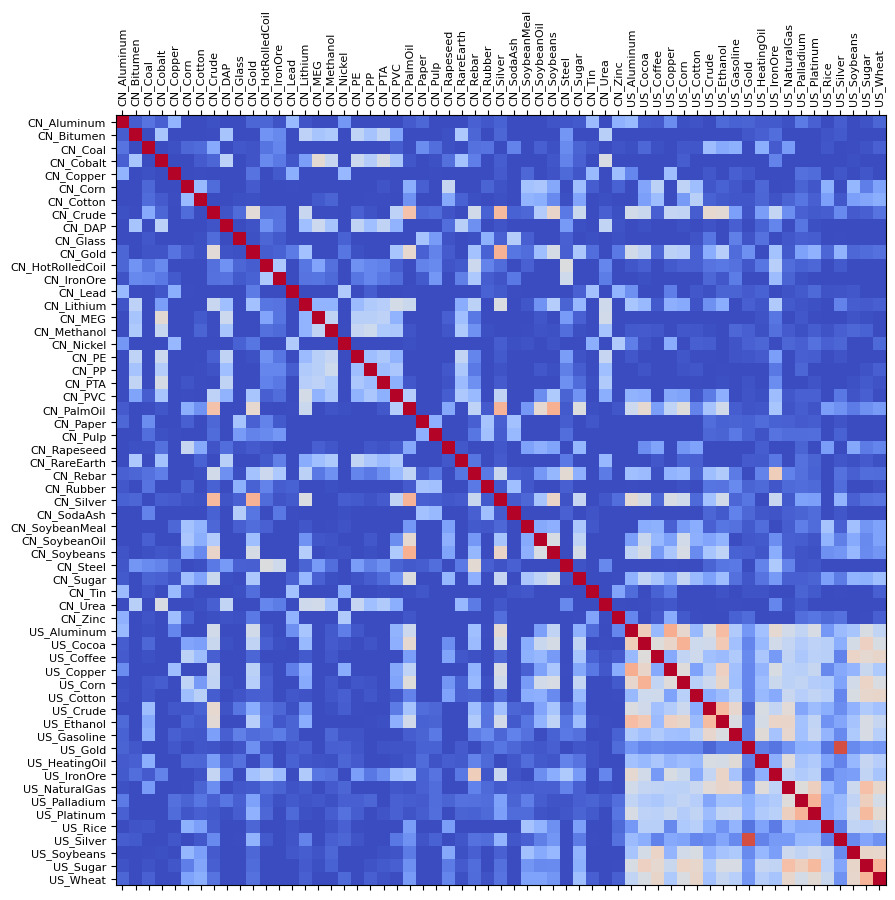

In [13]:
import matplotlib.cm as cm
start_d = pd.to_datetime('2018-09-30')
end_d = pd.to_datetime('2025-09-30')

log_f1 = np.log(f1_px.dropna(how='all').ffill())
logret = log_f1.diff()[(log_f1.index >= start_d) & (log_f1.index<=end_d)]

corr = logret.corr()
size = 10
fig, ax = plt.subplots(figsize=(size, size))
ax.matshow(corr,cmap=cm.get_cmap('coolwarm'), vmin=0,vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation='vertical', fontsize=8)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)
plt.show()

[48.         55.          0.47859814  2.        ]


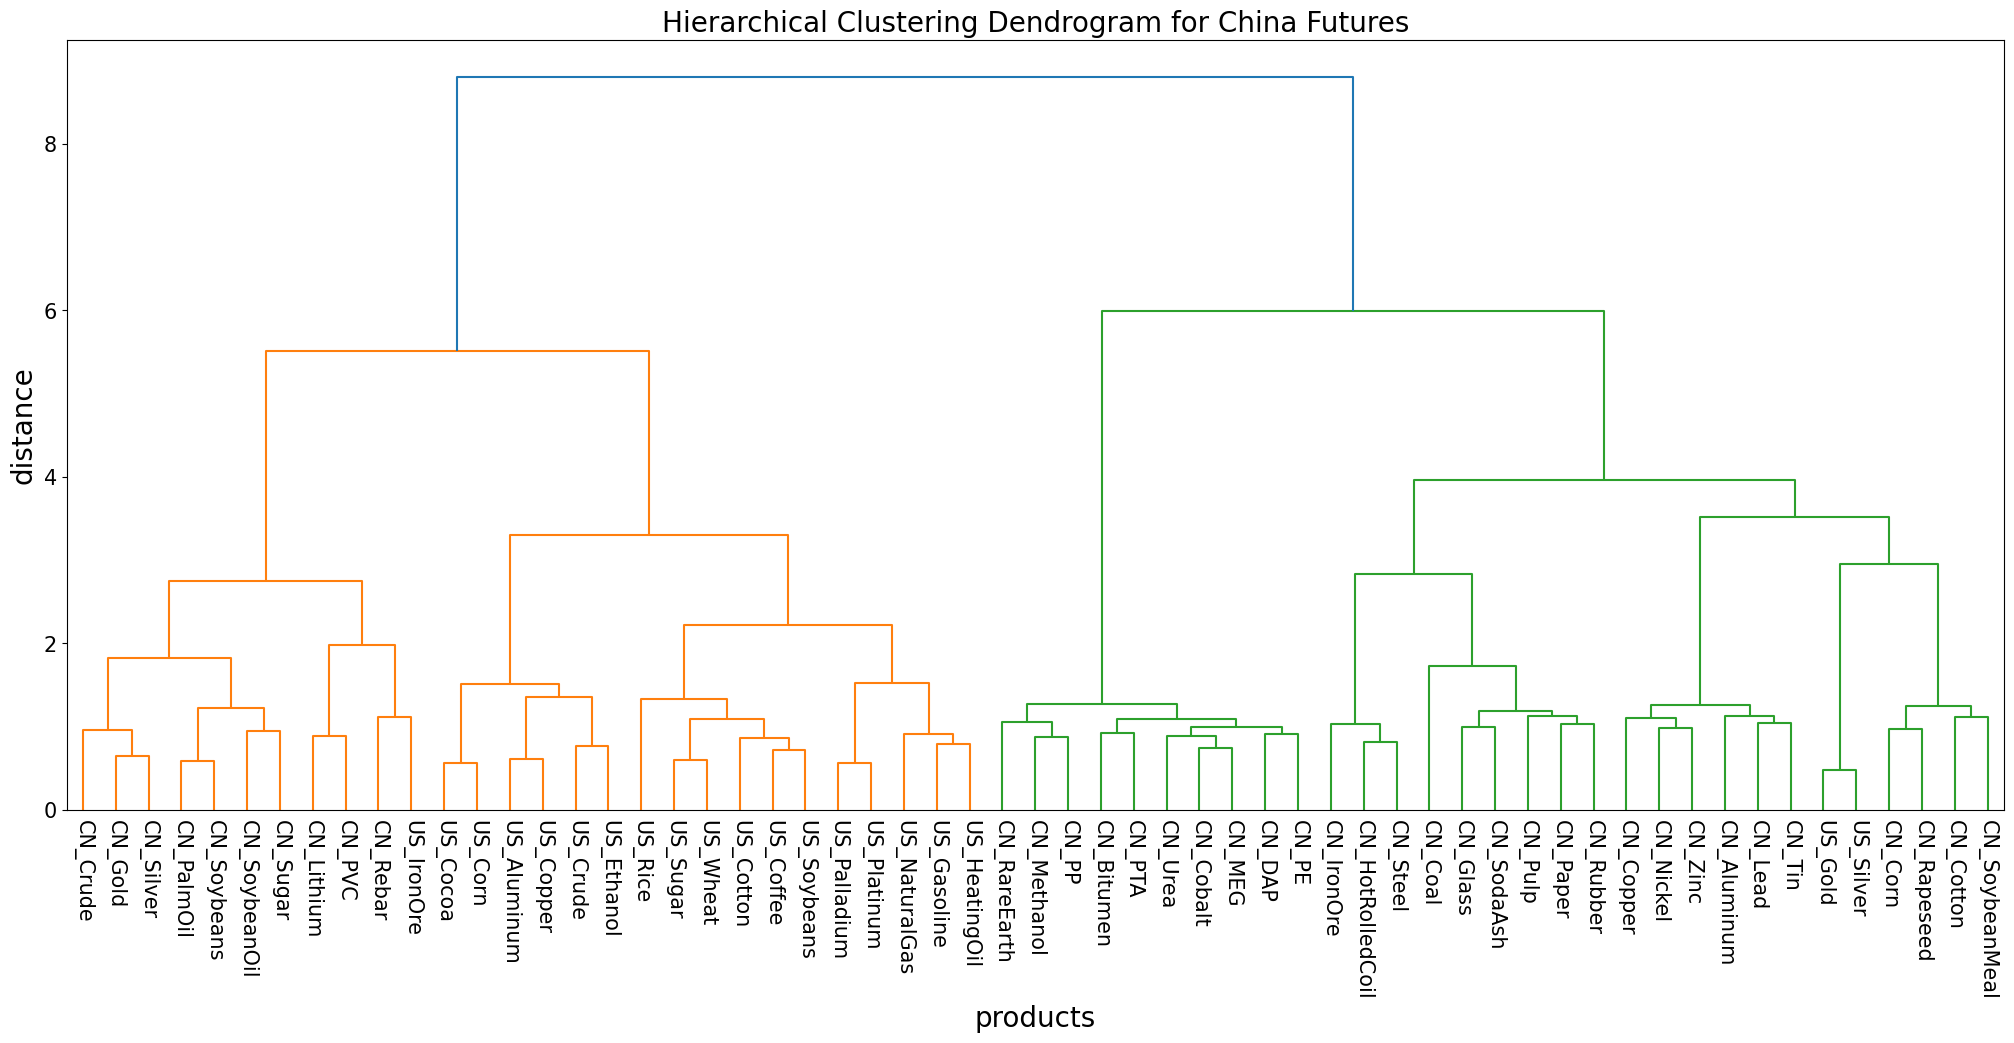

In [14]:
import scipy.cluster.hierarchy as sch 
from scipy.spatial.distance import pdist
import pylab

Z = sch.linkage(corr, 'ward')
print(Z[0])

# c, coph_dists = sch.cophenet(Z, pdist(corr))
# print(c)
plt.figure(figsize=(25, 10))
labelsize=20
ticksize=15
plt.title('Hierarchical Clustering Dendrogram for China Futures', fontsize=labelsize)
plt.xlabel('products', fontsize=labelsize)
plt.ylabel('distance', fontsize=labelsize)
sch.dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    labels = corr.columns
)
pylab.yticks(fontsize=ticksize)
pylab.xticks(rotation=-90, fontsize=ticksize)
plt.savefig('dendogram_'+'_fut'+'.png')
plt.show()

In [15]:
for key in alt_data.keys():
    display(alt_data[key].dropna().diff().corr())

,us_initial_jobless_claims,us_continuing_claims,us_m1_growth_yoy,us_m2_growth_yoy,us_commercial_paper_outstanding,us_redbook_retail_sales_yoy,us_consumer_credit_change,us_mortgage_applications,us_trade_balance,china_urban_unemployment,china_m1_growth_yoy,china_m2_growth_yoy,china_new_yuan_loans,china_total_social_financing,china_retail_sales_yoy,china_new_home_prices_yoy,china_exports_yoy,china_imports_yoy,baltic_dry_index
us_initial_jobless_claims,1.000000,-0.102265,0.122275,-0.073406,-0.057864,-0.034625,-0.037632,0.002269,-0.044922,0.010993,0.030272,0.092736,0.068608,0.017398,-0.003598,0.070519,-0.074471,-0.101633,-0.096221
us_continuing_claims,-0.102265,1.000000,0.058028,-0.027935,-0.012354,-0.029195,0.069224,0.073094,-0.084612,-0.074299,-0.022909,0.049508,-0.054657,-0.039104,0.080268,0.056807,0.095287,0.029751,0.030941
us_m1_growth_yoy,0.122275,0.058028,1.000000,0.051816,-0.142287,-0.008209,0.093696,0.003700,-0.102861,0.078446,0.041008,0.016337,-0.081240,0.037806,-0.115593,0.043144,-0.069028,-0.048672,0.002380
us_m2_growth_yoy,-0.073406,-0.027935,0.051816,1.000000,-0.018664,-0.045819,0.048887,-0.027619,0.037191,0.142802,0.010723,-0.069250,0.154444,0.055530,0.070946,-0.089112,0.057689,0.022487,0.111544
us_commercial_paper_outstanding,-0.057864,-0.012354,-0.142287,-0.018664,1.000000,0.062499,0.035071,-0.038032,0.025636,0.121722,0.097836,-0.052854,0.097116,0.054875,0.023042,0.006570,0.005308,-0.003395,0.087632
us_redbook_retail_sales_yoy,-0.034625,-0.029195,-0.008209,-0.045819,0.062499,1.000000,0.032685,-0.062640,-0.032361,-0.086827,0.008672,-0.015935,0.074225,0.010064,-0.017905,-0.100058,-0.075766,0.009600,0.049975
us_consumer_credit_change,-0.037632,0.069224,0.093696,0.048887,0.035071,0.032685,1.000000,0.005717,-0.008570,-0.047771,0.088316,-0.082688,0.118673,0.040196,0.045278,0.027403,0.067313,0.012863,-0.006087
us_mortgage_applications,0.002269,0.073094,0.003700,-0.027619,-0.038032,-0.062640,0.005717,1.000000,0.005017,-0.011268,-0.039302,-0.135339,0.091668,-0.008646,-0.010099,-0.035943,-0.037193,0.039531,-0.040046
us_trade_balance,-0.044922,-0.084612,-0.102861,0.037191,0.025636,-0.032361,-0.008570,0.005017,1.000000,0.079017,0.010343,-0.034604,-0.090359,0.064915,-0.002044,0.055826,0.012379,0.052606,-0.001788
china_urban_unemployment,0.010993,-0.074299,0.078446,0.142802,0.121722,-0.086827,-0.047771,-0.011268,0.079017,1.000000,0.023854,-0.104279,-0.053419,-0.050096,-0.029375,0.057363,0.125123,-0.063263,0.102303


,us_ism_manufacturing,us_ism_services,us_cpi_yoy,us_core_cpi_yoy,us_ppi_yoy,us_industrial_production_yoy,us_capacity_utilization,us_personal_consumption_yoy,us_durable_goods_orders_yoy,china_caixin_manufacturing_pmi,china_caixin_services_pmi,china_cpi_yoy,china_ppi_yoy,china_industrial_production_yoy,china_fixed_asset_investment_yoy,china_gdp_yoy,eurozone_manufacturing_pmi,japan_tankan_large_manufacturing,fed_funds_rate,china_loan_prime_rate,ecb_deposit_rate,boj_policy_rate
us_ism_manufacturing,1.000000,-0.121389,-0.240366,-0.071829,0.014076,-0.254914,0.163056,-0.032153,0.156683,0.113688,-0.152167,-0.023849,-0.016887,-0.030095,0.084349,0.073019,0.099000,0.001889,-0.163867,0.026572,0.138906,0.162602
us_ism_services,-0.121389,1.000000,-0.084602,-0.166219,-0.229288,0.064433,0.278874,-0.128215,0.274606,-0.059290,-0.043556,-0.020185,-0.203322,0.026128,-0.131474,0.102867,-0.033280,0.105165,0.238787,0.006219,-0.001626,0.039967
us_cpi_yoy,-0.240366,-0.084602,1.000000,0.024616,0.062017,-0.074792,0.061345,0.296050,-0.224895,0.011934,0.022178,0.002110,0.127626,-0.034089,-0.073315,0.038050,-0.200404,0.016588,0.156613,0.154545,0.026281,-0.084881
us_core_cpi_yoy,-0.071829,-0.166219,0.024616,1.000000,-0.015768,0.298452,-0.423654,0.188286,0.021115,-0.128253,0.034029,0.149555,0.180916,-0.041327,0.053407,0.196301,0.156097,-0.101185,0.031282,0.264156,-0.113035,0.056057
us_ppi_yoy,0.014076,-0.229288,0.062017,-0.015768,1.000000,-0.138148,0.066253,0.201047,-0.190598,-0.139715,0.188735,-0.116165,0.081645,0.050748,0.011171,0.000394,0.037921,-0.154489,0.021932,0.047114,0.050212,-0.235443
us_industrial_production_yoy,-0.254914,0.064433,-0.074792,0.298452,-0.138148,1.000000,-0.267039,0.313017,-0.017903,0.226236,-0.075518,0.079482,0.109146,-0.037925,0.117184,0.038675,-0.023887,-0.188755,0.037774,0.112033,-0.086439,-0.045841
us_capacity_utilization,0.163056,0.278874,0.061345,-0.423654,0.066253,-0.267039,1.000000,-0.118108,0.070339,-0.081666,-0.100435,-0.083182,-0.400388,0.020525,-0.051542,-0.057042,-0.149263,0.068288,0.027489,-0.206391,-0.059330,-0.126897
us_personal_consumption_yoy,-0.032153,-0.128215,0.296050,0.188286,0.201047,0.313017,-0.118108,1.000000,-0.013403,-0.069110,-0.021760,-0.127757,0.104289,-0.228440,0.079233,0.063017,-0.249420,-0.165180,-0.007482,0.112810,0.108285,-0.259083
us_durable_goods_orders_yoy,0.156683,0.274606,-0.224895,0.021115,-0.190598,-0.017903,0.070339,-0.013403,1.000000,0.020480,-0.269989,-0.025769,-0.093479,-0.297731,0.137284,0.197816,0.001426,0.098302,-0.253255,-0.014685,-0.060606,-0.091300
china_caixin_manufacturing_pmi,0.113688,-0.059290,0.011934,-0.128253,-0.139715,0.226236,-0.081666,-0.069110,0.020480,1.000000,-0.177595,0.283092,0.211632,0.377496,0.021238,0.215480,-0.071181,-0.096336,-0.172099,-0.018234,0.117019,0.100556


,USDCNY
USDCNY,1.0


,us_midwest_temp_anomaly,us_plains_temp_anomaly,us_corn_belt_precipitation,us_drought_monitor_d2_plus,brazil_temp_anomaly,argentina_temp_anomaly,australia_temp_anomaly,india_temp_anomaly,china_north_temp_anomaly,europe_temp_anomaly,brazil_precipitation,india_monsoon_strength,china_precipitation,australia_precipitation,brazil_drought_index,australia_drought_index,atlantic_hurricane_activity,pacific_typhoon_activity,us_corn_belt_soil_moisture,brazil_soil_moisture,us_corn_growing_degree_days,us_wheat_growing_degree_days
us_midwest_temp_anomaly,1.000000,0.038742,0.039172,-0.015766,-0.086963,-0.044899,0.072507,0.233283,0.089461,-0.133707,-0.035490,-0.118661,-0.133264,0.011557,-0.160235,-0.031546,-0.104182,0.010693,0.158612,-0.003511,0.033305,-0.005314
us_plains_temp_anomaly,0.038742,1.000000,-0.139558,-0.024244,-0.071609,0.012378,0.006280,0.059924,0.166135,-0.025228,-0.111985,-0.128790,-0.014402,-0.111596,-0.136750,-0.039095,-0.101861,-0.118650,0.002374,-0.044543,0.179861,-0.119590
us_corn_belt_precipitation,0.039172,-0.139558,1.000000,0.031355,-0.164523,0.077218,-0.154716,-0.208148,0.069324,0.119168,0.110486,0.185916,-0.092288,0.147037,0.109924,0.023063,0.096102,0.015006,0.059905,0.163973,-0.078265,-0.121942
us_drought_monitor_d2_plus,-0.015766,-0.024244,0.031355,1.000000,0.011423,-0.070204,-0.002695,-0.000037,-0.022964,-0.014447,0.058203,-0.096965,0.034672,-0.067499,-0.066176,0.058200,0.124243,0.124771,0.131406,0.044412,-0.078236,-0.061828
brazil_temp_anomaly,-0.086963,-0.071609,-0.164523,0.011423,1.000000,-0.083470,-0.057664,0.036702,0.022228,0.019467,0.043867,-0.057171,0.103814,0.143591,0.065449,-0.095088,-0.024029,-0.023701,0.123589,0.065602,-0.107855,0.210456
argentina_temp_anomaly,-0.044899,0.012378,0.077218,-0.070204,-0.083470,1.000000,0.051815,0.075037,-0.042468,0.134442,-0.162322,-0.035554,0.028949,0.061025,0.069698,-0.170462,-0.131461,-0.130820,-0.038486,0.009765,0.106894,0.001634
australia_temp_anomaly,0.072507,0.006280,-0.154716,-0.002695,-0.057664,0.051815,1.000000,0.172614,-0.062760,-0.137234,0.036699,-0.011440,0.151823,0.018895,-0.022827,0.154699,-0.034644,-0.146210,0.007929,0.050099,-0.030122,-0.063926
india_temp_anomaly,0.233283,0.059924,-0.208148,-0.000037,0.036702,0.075037,0.172614,1.000000,0.106133,-0.017440,-0.145759,-0.006152,-0.076981,-0.023627,-0.099007,0.049101,0.066191,-0.182860,0.075486,-0.050250,0.009654,0.057151
china_north_temp_anomaly,0.089461,0.166135,0.069324,-0.022964,0.022228,-0.042468,-0.062760,0.106133,1.000000,0.078073,0.067357,-0.046047,-0.149607,0.008379,0.093202,-0.012465,-0.051471,0.001676,0.039997,-0.137842,0.140091,0.069335
europe_temp_anomaly,-0.133707,-0.025228,0.119168,-0.014447,0.019467,0.134442,-0.137234,-0.017440,0.078073,1.000000,0.144720,0.123015,0.100574,0.112564,-0.101695,-0.056816,0.035938,-0.061401,0.120076,0.186773,0.022514,0.099713


,la_long_beach_congestion,shanghai_port_congestion,singapore_port_congestion,rotterdam_port_congestion,shanghai_la_container_rate,shanghai_rotterdam_container_rate,us_truck_tonnage_index,us_diesel_price,us_rail_carloads,us_rail_intermodal,us_warehouse_vacancy_rate,china_warehouse_vacancy_rate,global_air_freight_tons,air_freight_rate_index,global_supply_chain_pressure_index,semiconductor_lead_times_weeks
la_long_beach_congestion,1.000000,0.038198,-0.014497,-0.026564,0.079358,-0.008023,-0.093244,0.031728,0.134600,0.014825,-0.054262,-0.046011,-0.022758,0.078239,0.093406,0.033683
shanghai_port_congestion,0.038198,1.000000,0.020720,0.046766,0.045103,0.100835,-0.048830,0.011753,-0.028237,0.043038,-0.030930,0.067191,-0.078165,0.028104,0.031513,0.012026
singapore_port_congestion,-0.014497,0.020720,1.000000,-0.059008,-0.045202,-0.017768,0.023383,-0.013736,0.024413,-0.073759,-0.052989,0.058295,-0.063037,-0.014222,-0.022065,0.083844
rotterdam_port_congestion,-0.026564,0.046766,-0.059008,1.000000,-0.024482,0.067488,0.072281,0.012144,-0.076232,0.011494,0.110000,0.009709,0.073097,-0.014034,0.084431,0.026962
shanghai_la_container_rate,0.079358,0.045103,-0.045202,-0.024482,1.000000,0.042571,-0.063828,-0.008645,-0.013444,-0.063539,0.019051,-0.036575,-0.052802,-0.044226,0.002922,-0.037475
shanghai_rotterdam_container_rate,-0.008023,0.100835,-0.017768,0.067488,0.042571,1.000000,-0.036101,-0.021757,-0.026531,-0.091319,-0.003244,0.036593,0.082866,0.034014,0.078942,0.003489
us_truck_tonnage_index,-0.093244,-0.048830,0.023383,0.072281,-0.063828,-0.036101,1.000000,-0.026448,0.060574,-0.026093,-0.015499,0.070468,-0.036229,-0.062572,-0.013355,-0.101435
us_diesel_price,0.031728,0.011753,-0.013736,0.012144,-0.008645,-0.021757,-0.026448,1.000000,0.042763,0.054058,0.068490,0.040386,-0.042755,0.098463,-0.005152,-0.014105
us_rail_carloads,0.134600,-0.028237,0.024413,-0.076232,-0.013444,-0.026531,0.060574,0.042763,1.000000,-0.046981,-0.100631,-0.111541,0.013694,0.032100,-0.072797,-0.100076
us_rail_intermodal,0.014825,0.043038,-0.073759,0.011494,-0.063539,-0.091319,-0.026093,0.054058,-0.046981,1.000000,-0.078779,-0.016873,0.020091,0.061687,-0.036187,-0.088606


...

,vlcc_vessels_in_transit,suezmax_vessels_in_transit,capesize_vessels_in_transit,panamax_vessels_in_transit,vlcc_rate_persian_gulf_japan,capesize_rate_brazil_china,panamax_rate_usguld_china,suez_canal_transits_daily,panama_canal_transits_daily,singapore_bunker_price,rotterdam_bunker_price,houston_bunker_price
vlcc_vessels_in_transit,1.000000,0.060611,0.002488,0.089592,0.020657,0.009871,0.084272,-0.078309,0.014391,0.048732,0.033638,0.005335
suezmax_vessels_in_transit,0.060611,1.000000,0.012168,-0.038618,-0.040465,-0.044382,0.048096,0.025077,0.049381,0.033280,0.103250,-0.059672
capesize_vessels_in_transit,0.002488,0.012168,1.000000,0.079258,0.078283,0.094246,-0.003769,-0.044401,-0.043557,-0.111900,-0.035995,0.084709
panamax_vessels_in_transit,0.089592,-0.038618,0.079258,1.000000,0.039477,-0.013446,-0.002960,-0.049258,0.039675,-0.086480,0.094005,0.060111
vlcc_rate_persian_gulf_japan,0.020657,-0.040465,0.078283,0.039477,1.000000,-0.063174,-0.116002,-0.100478,0.044853,0.060299,0.057655,0.078855
capesize_rate_brazil_china,0.009871,-0.044382,0.094246,-0.013446,-0.063174,1.000000,-0.068671,0.004457,0.101303,-0.081197,-0.009621,0.011318
panamax_rate_usguld_china,0.084272,0.048096,-0.003769,-0.002960,-0.116002,-0.068671,1.000000,0.096864,-0.023871,0.012169,-0.040177,0.012765
suez_canal_transits_daily,-0.078309,0.025077,-0.044401,-0.049258,-0.100478,0.004457,0.096864,1.000000,-0.051627,-0.029402,-0.099547,-0.104830
panama_canal_transits_daily,0.014391,0.049381,-0.043557,0.039675,0.044853,0.101303,-0.023871,-0.051627,1.000000,0.045185,0.114231,0.132603
singapore_bunker_price,0.048732,0.033280,-0.111900,-0.086480,0.060299,-0.081197,0.012169,-0.029402,0.045185,1.000000,0.111589,-0.089385


,us_crude_inventory,us_gasoline_inventory,us_distillate_inventory,oecd_total_oil_inventory,us_refinery_utilization,china_refinery_utilization,global_refinery_margins,us_nat_gas_storage,europe_nat_gas_storage_pct,global_solar_capacity_additions_gw,global_wind_capacity_additions_gw,china_coal_inventory_days,newcastle_coal_price,us_electricity_demand_gwh,china_electricity_demand_gwh
us_crude_inventory,1.000000,0.035582,0.022630,-0.097570,-0.002438,-0.024824,-0.009614,0.006842,0.030093,0.047373,0.060049,-0.014761,0.060657,-0.030550,-0.098518
us_gasoline_inventory,0.035582,1.000000,0.071623,-0.087527,0.063457,0.028407,0.010294,-0.016018,-0.045649,-0.043894,-0.040255,-0.005989,0.054054,-0.013369,0.023578
us_distillate_inventory,0.022630,0.071623,1.000000,-0.030303,0.024165,-0.070611,-0.012940,-0.044361,0.026850,0.074800,0.017070,0.094464,0.007165,-0.149007,0.077287
oecd_total_oil_inventory,-0.097570,-0.087527,-0.030303,1.000000,-0.020850,0.181359,-0.096834,0.000629,0.133503,-0.038749,0.035304,0.032922,0.064563,0.246020,0.035214
us_refinery_utilization,-0.002438,0.063457,0.024165,-0.020850,1.000000,-0.031607,0.026533,0.047831,-0.069053,0.139456,-0.064425,-0.138050,0.036043,-0.042913,0.062737
china_refinery_utilization,-0.024824,0.028407,-0.070611,0.181359,-0.031607,1.000000,-0.091155,0.020097,0.067443,-0.053680,0.133877,-0.067123,-0.076883,0.038039,0.069615
global_refinery_margins,-0.009614,0.010294,-0.012940,-0.096834,0.026533,-0.091155,1.000000,-0.056496,-0.069377,0.041403,-0.089542,0.013814,-0.005948,-0.013700,-0.036030
us_nat_gas_storage,0.006842,-0.016018,-0.044361,0.000629,0.047831,0.020097,-0.056496,1.000000,-0.099428,0.106358,0.020712,-0.038745,-0.067874,-0.046408,-0.002509
europe_nat_gas_storage_pct,0.030093,-0.045649,0.026850,0.133503,-0.069053,0.067443,-0.069377,-0.099428,1.000000,-0.063289,0.101707,0.019268,-0.019258,0.008306,-0.019255
global_solar_capacity_additions_gw,0.047373,-0.043894,0.074800,-0.038749,0.139456,-0.053680,0.041403,0.106358,-0.063289,1.000000,-0.037675,-0.025762,-0.105622,0.036345,-0.007195


,us_corn_condition,us_soybean_condition,us_wheat_condition,us_corn_planting_progress,us_soybean_planting_progress,brazil_soybean_harvest_progress,us_corn_export_sales,us_soybean_export_sales,us_wheat_export_sales,us_cattle_on_feed,us_hog_inventory,china_hog_inventory,us_soybean_crush_margin,china_soybean_crush_margin,urea_price,dap_price,potash_price
us_corn_condition,1.000000,0.025832,-0.002063,-0.078535,0.128576,0.049642,0.030212,0.025915,-0.005383,0.043779,-0.113408,-0.027818,-0.051491,0.088142,-0.061923,0.030390,-0.068110
us_soybean_condition,0.025832,1.000000,0.070289,0.033344,-0.028012,0.054377,-0.050920,0.071579,-0.005043,-0.070454,-0.018342,-0.073558,-0.166986,0.029909,-0.085007,0.004751,-0.060325
us_wheat_condition,-0.002063,0.070289,1.000000,-0.031936,-0.065465,0.016639,-0.073636,-0.054921,0.086713,0.026887,-0.039958,0.043965,0.051507,0.018806,0.004705,-0.068793,-0.064851
us_corn_planting_progress,-0.078535,0.033344,-0.031936,1.000000,0.013630,0.035730,-0.066248,-0.003533,-0.063008,-0.025581,-0.005496,0.016131,-0.043935,0.005114,0.005793,-0.121899,0.036223
us_soybean_planting_progress,0.128576,-0.028012,-0.065465,0.013630,1.000000,-0.146753,-0.048813,-0.015264,0.029963,-0.009373,0.002105,0.008614,-0.061430,-0.085671,0.039973,0.009124,-0.076646
brazil_soybean_harvest_progress,0.049642,0.054377,0.016639,0.035730,-0.146753,1.000000,-0.083318,-0.053891,0.066013,-0.048943,-0.079632,0.074708,-0.073757,0.014334,-0.143888,0.071242,-0.112203
us_corn_export_sales,0.030212,-0.050920,-0.073636,-0.066248,-0.048813,-0.083318,1.000000,-0.008594,-0.007301,-0.088683,-0.018864,-0.039889,-0.060821,-0.078913,-0.022936,0.038582,0.036089
us_soybean_export_sales,0.025915,0.071579,-0.054921,-0.003533,-0.015264,-0.053891,-0.008594,1.000000,-0.014577,0.114125,0.010022,0.028642,-0.052491,0.017464,0.012335,-0.006145,0.044905
us_wheat_export_sales,-0.005383,-0.005043,0.086713,-0.063008,0.029963,0.066013,-0.007301,-0.014577,1.000000,-0.104416,-0.014486,-0.098694,0.023062,0.042387,0.039525,0.019923,-0.148306
us_cattle_on_feed,0.043779,-0.070454,0.026887,-0.025581,-0.009373,-0.048943,-0.088683,0.114125,-0.104416,1.000000,0.102788,0.028488,0.199554,-0.113853,0.116023,-0.011664,-0.004330


,global_steel_production,china_steel_production,global_aluminum_production,global_copper_production,chile_copper_output,peru_copper_output,australia_iron_ore_exports,brazil_iron_ore_exports,global_semiconductor_sales,global_auto_production,china_excavator_sales,china_property_starts,us_housing_starts,china_cement_production,global_ethylene_production,china_methanol_production
global_steel_production,1.000000,0.032755,0.068829,-0.006327,-0.072884,-0.011865,-0.010165,0.055032,0.015362,-0.048450,-0.061621,0.032316,-0.075912,0.026431,0.043423,-0.078748
china_steel_production,0.032755,1.000000,0.044635,0.086182,0.006180,-0.053282,0.021361,0.001987,0.044125,0.027919,-0.040824,0.089264,0.033354,-0.104066,-0.107367,0.033070
global_aluminum_production,0.068829,0.044635,1.000000,-0.053089,0.005369,-0.073867,-0.061817,-0.019314,-0.073115,0.088661,-0.057763,-0.073533,-0.139504,0.032417,-0.058665,0.019965
global_copper_production,-0.006327,0.086182,-0.053089,1.000000,-0.054943,0.003430,0.106042,0.027841,0.030943,-0.101415,0.053703,-0.005084,0.093048,0.014266,0.071816,-0.029888
chile_copper_output,-0.072884,0.006180,0.005369,-0.054943,1.000000,0.046208,-0.088877,0.008212,-0.012188,0.112899,0.036497,-0.015195,-0.007637,0.041584,-0.029185,0.082703
peru_copper_output,-0.011865,-0.053282,-0.073867,0.003430,0.046208,1.000000,-0.071197,0.019378,-0.073287,-0.013525,-0.155016,0.087250,0.054258,0.038898,0.020561,-0.023010
australia_iron_ore_exports,-0.010165,0.021361,-0.061817,0.106042,-0.088877,-0.071197,1.000000,0.052209,0.083541,-0.028478,-0.039696,0.046184,-0.004103,0.029492,0.025519,-0.103523
brazil_iron_ore_exports,0.055032,0.001987,-0.019314,0.027841,0.008212,0.019378,0.052209,1.000000,-0.011171,0.106124,0.004771,0.043145,0.063893,-0.007464,0.043227,0.001034
global_semiconductor_sales,0.015362,0.044125,-0.073115,0.030943,-0.012188,-0.073287,0.083541,-0.011171,1.000000,-0.046854,-0.011451,-0.017660,0.018793,0.024976,-0.079612,-0.010310
global_auto_production,-0.048450,0.027919,0.088661,-0.101415,0.112899,-0.013525,-0.028478,0.106124,-0.046854,1.000000,-0.042787,-0.018861,-0.032390,0.042675,-0.088528,0.099097


,dxy_index,euro_index,jpyusd_rate,us_10y_yield,us_2y_yield,german_10y_yield,china_10y_yield,us_ig_spread,us_hy_spread,em_spread,sp500_level,vix_level,shanghai_composite,audusd_rate,cadusd_rate,nokusd_rate,zarusd_rate,brlusd_rate
dxy_index,1.000000,-0.011619,-0.065284,0.046988,-0.018127,0.001543,0.028264,0.010735,0.030963,-0.001119,0.045798,-0.000534,0.000160,-0.006555,-0.041532,-0.002298,-0.026626,-0.036932
euro_index,-0.011619,1.000000,-0.007222,-0.022383,-0.007732,0.013603,-0.000765,0.055597,0.017168,0.025776,0.003072,0.008652,-0.013528,-0.002616,-0.002724,-0.044710,-0.006379,-0.001590
jpyusd_rate,-0.065284,-0.007222,1.000000,0.008834,0.013274,0.064949,-0.032106,-0.041963,0.011337,0.036730,0.020296,0.038206,-0.022591,0.074664,0.002459,0.013766,0.063427,0.023205
us_10y_yield,0.046988,-0.022383,0.008834,1.000000,0.007076,-0.027647,-0.008130,-0.044096,-0.056129,0.032161,0.009944,-0.004827,-0.012960,0.031583,0.000603,-0.000040,-0.032647,-0.016578
us_2y_yield,-0.018127,-0.007732,0.013274,0.007076,1.000000,0.010779,-0.027174,0.037157,0.067753,0.046174,0.016969,-0.005346,-0.002676,0.008230,-0.026274,0.018777,-0.006151,-0.004577
german_10y_yield,0.001543,0.013603,0.064949,-0.027647,0.010779,1.000000,-0.006132,0.006696,-0.013899,0.014660,0.039422,-0.012703,0.000284,0.034995,0.030031,-0.000761,0.047304,0.055453
china_10y_yield,0.028264,-0.000765,-0.032106,-0.008130,-0.027174,-0.006132,1.000000,-0.035799,0.008054,-0.036329,-0.018450,0.008686,0.040699,-0.021406,0.018101,0.010500,0.041323,-0.019415
us_ig_spread,0.010735,0.055597,-0.041963,-0.044096,0.037157,0.006696,-0.035799,1.000000,0.026109,-0.023306,0.000015,0.007865,-0.019923,0.024283,-0.032069,0.005089,-0.029714,0.039191
us_hy_spread,0.030963,0.017168,0.011337,-0.056129,0.067753,-0.013899,0.008054,0.026109,1.000000,-0.023863,-0.004251,0.020298,-0.043165,0.024610,-0.000873,-0.012765,-0.072518,-0.007198
em_spread,-0.001119,0.025776,0.036730,0.032161,0.046174,0.014660,-0.036329,-0.023306,-0.023863,1.000000,0.033354,0.028333,0.047222,0.000374,-0.003212,0.038333,0.017126,-0.015547


some functions for backtest and IC/IR (some generated by GPT)

In [16]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant
from scipy.stats import spearmanr, pearsonr
from numpy.lib.stride_tricks import sliding_window_view
import seaborn as sns

def sharpe(ts, business_days_per_year=252):
    return ts.mean() / ts.std() * np.sqrt(business_days_per_year)

def calc_perf_by_tenors(ts, tenors, metric='sharpe', business_days_per_year=244):
    func_dict = {
        'sharpe': sharpe,
    }
    edate = ts.index[-1]
    result = {}
    for tenor in tenors:
        if tenor[-1] == 'y':
            sdate = edate - pd.DateOffset(years=int(tenor[:-1]))
        elif tenor[-1] == 'm':
            sdate = edate - pd.DateOffset(months=int(tenor[:-1]))
        elif  tenor[-1] == 'd':
            sdate = edate - pd.DateOffset(days=int(tenor[:-1]))
        else:
            continue
        sample = ts.loc[sdate:]
        if metric in func_dict:
            result[f'{metric}_{tenor}'] = func_dict[metric](sample)
        else:
            result[f'{metric}_{tenor}'] = getattr(sample, metric)()
    result = pd.DataFrame([result]).T[0]
    return result

def rolling_percentile(ts, win=100, direction='max'):
    ts = ts.dropna().copy(deep=True)
    data = ts.to_numpy()
    sw = sliding_window_view(data, win, axis=0).T
    scores_np = np.empty(len(ts))
    scores_np.fill(np.nan)
    scores_np[(win-1):] = ((sw <= sw[-1:, ...]).sum(axis=0).T / sw.shape[0]).flatten()
    scores_np_ts = (pd.Series(scores_np, index = ts.index) - 1/win) / (1 - 1/win)
    if direction == 'min':
        scores_np_ts = 1 - scores_np_ts
    return scores_np_ts

def zscore_roll(ts, win, alpha=1):
    return (ts.rolling(alpha).mean() - ts.rolling(win).mean())/ts.rolling(win).std()

def pct_score(ts: pd.Series, win: int):
    if len(ts) < win:
        res = pd.Series(0, index=ts.index)
    else:
        res = rolling_percentile(ts, win) * 2 -1.0
    return res

def hlratio(ts, win=80):
    ll = ts.rolling(win).min()
    hh = ts.rolling(win).max()
    return (ts - ll) / (hh - ll) * 2 - 1.0

def compute_corr(x, y, method="spearman"):
    """Compute correlation and p-value safely."""
    mask = x.notna() & y.notna()
    if mask.sum() < 10:
        return np.nan, np.nan, mask.sum()
    x, y = x[mask], y[mask]
    if method == "spearman":
        c, p = spearmanr(x, y)
    else:
        c, p = pearsonr(x, y)
    return c, p

def rolling_beta(y, x, window=60):
    """
    Compute rolling regression beta of y on x.
    Returns Series of betas aligned with y.index.
    """
    betas = pd.Series(index=y.index, dtype=float)
    for i in range(window, len(y)):
        y_sub = y.iloc[i-window:i]
        x_sub = x.iloc[i-window:i]
        if y_sub.isna().any() or x_sub.isna().any():
            continue
        model = OLS(y_sub, add_constant(x_sub)).fit()
        betas.iloc[i] = model.params[1] if len(model.params) > 1 else np.nan
    return betas

def compute_forward_returns(px_df, horizons=(1, 3, 5), shift=0):
    fwd_returns = {}
    for h in horizons:
        fwd_returns[h] = px_df.shift(-shift - h) / px_df.shift(-shift) - 1
    return fwd_returns


def build_feature_return_panel(
        px_df: pd.DataFrame,
        spot_df: pd.DataFrame,
        feature_name: str,
        forward_windows=(1, 3, 5),
        beta_window=60,
        default_group: str = "all"
        ):
    """
    Given price DataFrame (cols = assets) and feature Series (index = dates),
    aligns them, computes forward returns at feature dates,
    and builds a long panel with [date, asset, feature, fwd_return_h].
    
    If feature_name is common (in spot_df.columns), compute rolling beta
    of each asset's return to that feature, and use beta * feature as score.

    Returns:
        panel DataFrame with columns:
        ['date', 'asset', 'feature', 'score', 'horizon', 'forward_return']
    """
    if isinstance(px_df.columns, pd.MultiIndex):
        col_index = px_df.columns
    else:
        col_index = pd.MultiIndex.from_product(
            [px_df.columns, [default_group]], names=["asset", "group"]
        )
        px_df.columns = col_index

    assets = col_index.get_level_values("asset").unique()
    groups = dict(col_index)

    # --- Identify feature type ---
    if feature_name in spot_df:
        feature_type = "common"
        feature_ts = spot_df[feature_name].dropna()
    else:
        feature_type = "asset_specific"
        asset_cols = [
            f"{asset}_{feature_name}" for asset in assets if f"{asset}_{feature_name}" in spot_df.columns
        ]
        feature_ts = spot_df[asset_cols].dropna(how='all')

    # --- Align data ---
    px_aligned = px_df.reindex(index=feature_ts.index, method='ffill').sort_index()
    ret_df = px_aligned.pct_change()

    # --- Forward returns ---
    fwd_returns = {}
    for h in forward_windows:
        fwd_returns[h] = px_aligned.shift(-h) / px_aligned - 1.0
    fwd_df = pd.concat(fwd_returns, axis=1)  # MultiIndex columns: (horizon, asset)

    # --- Rolling beta computation for common feature ---
    if feature_type == "common" and beta_window > 0:
        f = feature_ts.loc[ret_df.index]
        f_mean = f.rolling(beta_window).mean()
        f_var = f.rolling(beta_window).var()

        betas = pd.DataFrame(index=ret_df.index, columns=assets, dtype=float)
        for (asset, group) in ret_df.columns:
            r = ret_df[(asset, group)]
            cov_rf = (r * f).rolling(beta_window).mean() - r.rolling(beta_window).mean() * f_mean
            betas[(asset, group)] = cov_rf / f_var

        # Compute score = beta * feature value
        score_df = betas.mul(f, axis=0)

    # --- Build panel ---
    panels = []
    for h in forward_windows:
        fwd_tmp = (
            fwd_df[h]
            .stack(level=["asset", "group"])
            .rename("forward_return")
            .reset_index()
            .rename(columns={"level_0": "date"})
        )
        fwd_tmp["horizon"] = h

        if feature_type == "common":
            fwd_tmp["feature"] = feature_ts.reindex(fwd_tmp["date"]).values
            if beta_window > 0:
                fwd_tmp["beta"] = [
                    score_df.at[dt, (asset, group)] / feature_ts.at[dt] 
                    if (dt in score_df.index and feature_ts.at[dt] != 0) 
                    else np.nan
                    for dt, asset, group in zip(
                        fwd_tmp["date"], fwd_tmp["asset"], fwd_tmp["group"]
                    )
                ]
                fwd_tmp["score"] = [
                    score_df.at[dt, (asset, group)] 
                    if dt in score_df.index 
                    else np.nan
                    for dt, asset, group in zip(
                        fwd_tmp["date"], fwd_tmp["asset"], fwd_tmp["group"]
                    )
                ]
            else:
                fwd_tmp["beta"] = np.nan
                fwd_tmp["score"] = fwd_tmp["feature"]
        else:
            # Asset-specific feature
            fwd_tmp["feature"] = [
                feature_ts.at[dt, f"{asset}_{feature_name}"] 
                if dt in feature_ts.index and f"{asset}_{feature_name}" in feature_ts.columns
                else np.nan
                for dt, asset in zip(fwd_tmp["date"], fwd_tmp["asset"])
            ]
            fwd_tmp["score"] = fwd_tmp["feature"]
            fwd_tmp["beta"] = np.nan

        panels.append(fwd_tmp)

    panel = pd.concat(panels, ignore_index=True)
    panel = panel.dropna(subset=["score", "forward_return"]).sort_values(["date", "asset"])
    return panel


def analyze_feature_ic_ir_ts(
        panel: pd.DataFrame, 
        method: str ="spearman",
        sector_analysis: bool = True,
        group_col: str = "group"
        ):

    results, asset_list, sector_list = [], [], []
    corr_func = spearmanr if method == "spearman" else pearsonr

    for h, dfh in panel.groupby("horizon"):
        asset_corrs = []
        for asset, sub in dfh.groupby("asset"):
            mask = sub["score"].notna() & sub["forward_return"].notna()
            if mask.sum() < 10:
                continue
            c, p = corr_func(sub.loc[mask, "score"], sub.loc[mask, "forward_return"])
            asset_corrs.append({"asset": asset, "horizon": h, "ic": c, "pval": p})
        per_asset_df = pd.DataFrame(asset_corrs)
        asset_list.append(per_asset_df)

        if sector_analysis and group_col in dfh.columns:
            sector_corrs = []
            for sector, sub in dfh.groupby(group_col):
                sector_ts = (
                    sub.groupby("date")[["score", "forward_return"]].mean().dropna()
                )
                if len(sector_ts) < 10:
                    continue
                c, p = corr_func(sector_ts["score"], sector_ts["forward_return"])
                sector_corrs.append({"sector": sector, "horizon": h, "ic": c, "pval": p})
            per_sector_df = pd.DataFrame(sector_corrs)
            sector_list.append(per_sector_df)
        else:
            per_sector_df = pd.DataFrame()

        asset_mean_ic = per_asset_df["ic"].mean()
        asset_ir = (
            asset_mean_ic / per_asset_df['ic'].std()
            if per_asset_df['ic'].std() > 0
            else np.nan
        )
        if not per_asset_df.empty:
            sector_mean_ic = per_sector_df['ic'].mean()
            sector_ir = (
                sector_mean_ic / per_sector_df['ic'].std()
                if per_asset_df['ic'].std() > 0
                else np.nan
            )
        else:
            sector_mean_ic, sector_ir = np.nan, np.nan

        results.append({
            "horizon": h,
            "asset_mean_ic": asset_mean_ic,
            "asset_ir": asset_ir,
            "sector_mean_id": sector_mean_ic,
            "sector_ir": sector_ir,
            "n_assets": per_asset_df["asset"].nunique(),
            "n_sectors": per_sector_df["sector"].nunique() if not per_sector_df.empty else 0,
        })

    return {
        "summary": pd.DataFrame(results),
        "per_asset_ic": pd.concat(asset_list, ignore_index=True),
        "per_sector_ic": pd.concat(sector_list, ignore_index=True) if sector_list else pd.DataFrame(),
    }


def analyze_feature_ic_ir_xs(
        panel: pd.DataFrame, 
        method="spearman",
        group_col: str = "group"
        ):
    results, date_list, sector_list = [], [], []
    corr_func = spearmanr if method == "spearman" else pearsonr

    for h, dfh in panel.groupby("horizon"):
        date_corrs = []
        for date, sub in dfh.groupby("asset"):
            mask = sub["score"].notna() & sub["forward_return"].notna()
            if sub.loc[mask, "score"].nunique() <= 1:
                continue
            c, p = corr_func(sub.loc[mask, "score"], sub.loc[mask, "forward_return"])
            date_corrs.append({"date": date, "horizon": h, "ic": c, "pval": p})
        per_date_df = pd.DataFrame(date_corrs)
        date_list.append(per_date_df)

        sector_corrs = []
        if group_col in dfh.columns:
            for (date, sector), sub in dfh.groupby(["date", group_col]):
                mask = sub["score"].notna() & sub["forward_return"].notna()
                if sub.loc[mask, "score"].nunique() <= 1:
                    continue
                c, p = corr_func(sub.loc[mask, "score"], sub.loc[mask, "forward_return"])
                sector_corrs.append({
                    "date": date,
                    "sector": sector,
                    "horizon": h,
                    "ic": c,
                    "pval": p
                })
            per_sector_df = pd.DataFrame(sector_corrs)
            sector_list.append(per_sector_df)
        else:
            per_sector_df = pd.DataFrame()

        mean_ic = per_date_df["ic"].mean()
        ir = mean_ic / per_date_df["ic"].std() if per_date_df["ic"].std() > 0 else np.nan

        if not per_sector_df.empty:
            sector_mean_ic = per_sector_df.groupby("sector")["ic"].mean().mean()
            sector_ir = per_sector_df.groupby("sector").apply(
                lambda x: x["ic"].mean() / x["ic"].std() if x["ic"].std() > 0 else np.nan
            ).mean()
        else:
            sector_mean_ic, sector_ir = np.nan, np.nan

        results.append({
            "horizon": h,
            "global_mean_ic": mean_ic,
            "global_ir": ir,
            "sector_mean_ic": sector_mean_ic,
            "sector_ir": sector_ir,
            "n_dates": len(per_date_df),
            "n_sectors": per_sector_df["sector"].nunique() if not per_sector_df.empty else 0,
        })

    return {
        "summary": pd.DataFrame(results),
        "per_date_ic": pd.concat(date_list, ignore_index=True),
        "per_sector_ic": pd.concat(sector_list, ignore_index=True) if sector_list else pd.DataFrame()
    }


In [17]:
def calc_conv_signal(feature_ts, signal_func, param_rng, signal_cap=2.5, vol_win=120):
    sig_list = []
    for win in range(*param_rng):
        if len(feature_ts) <= win:
            continue
        if signal_func == 'ma':
            signal_ts = feature_ts.rolling(win, min_periods=win//2).mean() \
                        / feature_ts.abs().rolling(vol_win, min_periods=vol_win//2).mean()
        elif signal_func == 'ma_dff_sgn':
            signal_ts = np.sign(feature_ts - feature_ts.rolling(win).mean())
        elif signal_func == 'zscore':
            signal_ts = zscore_roll(feature_ts, win=win)
        elif signal_func == 'qtl':
            signal_ts = pct_score(feature_ts.dropna(), win=win)
        elif signal_func == 'hlratio':
            signal_ts = hlratio(feature_ts, win=win)
        else:
            continue
        if signal_cap:
            if type(signal_cap) == list:
                signal_ts = signal_ts.clip(signal_cap[0], signal_cap[1])
            else:
                signal_ts = signal_ts.clip(-signal_cap, signal_cap)
        sig_list.append(signal_ts)
    if len(sig_list) > 0:
        conv_signal = pd.concat(sig_list, axis=1).mean(axis=1)
    else:
        conv_signal = pd.Series()
    return conv_signal

def signal_generator(spot_df, feature, signal_func, param_rng,
                     proc_func='', chg_func='diff', bullish=True,
                     signal_cap=[-2, 2], post_func='', vol_win=120):
    feature_ts = spot_df[feature].dropna()
    start_date = spot_df.index[0]
    end_date = spot_df.index[-1]
    cdates = pd.date_range(start=start_date, end=end_date, freq='D')
    bdates = pd.bdate_range(start=start_date, end=end_date, freq='C')

    if '|' in proc_func:
        proc_func_list = proc_func.split('|')
    else:
        proc_func_list = [proc_func]

    for pfunc in proc_func_list:
        if 'df' in pfunc:
            n_diff = int(pfunc[2:])
            feature_ts = getattr(feature_ts, chg_func)(n_diff)
        elif 'sma' in pfunc:
            n_days = int(pfunc[3:])
            feature_ts = feature_ts.rolling(n_days).mean()
        elif 'ema' in pfunc:
            n_days = int(pfunc[3:])
            feature_ts = feature_ts.ewm(n_days).mean()            
        elif 'lr' in pfunc:
            feature_ts = np.log(1 + feature_ts)
    if len(signal_func)>0:
        signal_ts = calc_conv_signal(feature_ts, signal_func=signal_func, param_rng=param_rng,
                                     signal_cap=signal_cap, vol_win=vol_win)
    else:
        signal_ts = feature_ts

    if not bullish:
        signal_ts = -signal_ts

    if len(post_func) > 0:
        signal_ts = signal_ts.reindex(index=cdates).ffill().reindex(index=bdates)
        if '|' in post_func:
            post_func_list = post_func.split('|')
        else:
            post_func_list = [post_func]
        for pfunc in post_func_list:
            if pfunc[:3] == 'ema':
                n_win = int(pfunc[3:])
                signal_ts = signal_ts.ewm(n_win, ignore_na=True).mean()
            elif pfunc[:3] == 'sma':
                n_win = int(pfunc[3:])
                signal_ts = signal_ts.rolling(n_win).mean()
            elif pfunc[:3] == 'pos':
                signal_ts = signal_ts.apply(lambda x: x if x > 0 else 0)
            elif pfunc[:3] == 'neg':
                signal_ts = signal_ts.apply(lambda x: x if x < 0 else 0)         
            elif pfunc[:3] == 'sgn':
                signal_ts = np.sign(signal_ts)  
    return signal_ts

In [18]:
px_df = f1_px.copy()
commod_sector_map = commodity_info[["commodity", "sector"]].set_index("commodity")['sector'].to_dict()
px_df.columns = pd.MultiIndex.from_tuples([(asset, commod_sector_map[asset]) for asset in f1_px.columns])
px_df.columns.names = ['asset', 'group']
sector_map = commodity_info.groupby("sector")["commodity"].apply(list).to_dict()

In [19]:
def np_nanmean_nowarning(nd_in, axis=0, keepdims=True):
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        means = np.nanmean(nd_in, axis=axis, keepdims=keepdims)
    return means

def xs_mean(df_in):
    means = np_nanmean_nowarning(df_in.values, axis=1)
    series_out = pd.Series(means, index=df_in.index)
    return series_out

def xs_mean_repeat(df_in):
    means = np_nanmean_nowarning(df_in.values, axis=1)
    mean_repeat = np.repeat(means, len(df_in.columns), axis=1)
    mean_repeat[np.isnan(df_in.values)] = np.nan
    df_out = pd.DataFrame(mean_repeat, index=df_in.index, columns=df_in.columns)
    return df_out


def xs_demean(df_in):
    df_out = df_in - xs_mean_repeat(df_in)
    return df_out

def xs_sec_demean(df_in, sector_map=sector_map) -> pd.DataFrame:
    df_demeaned = df_in.copy()
    for sector, commodities in sector_map.items():
        valid_cols = [c for c in commodities if c in df_in.columns]
        if not valid_cols:
            continue
        sector_mean = df_in[valid_cols].mean(axis=1)
        df_demeaned[valid_cols] = df_in[valid_cols].subtract(sector_mean, axis=0)
    return df_demeaned

def xs_score(df_in, demean=True):
    if demean:
        df_demeaned = xs_demean(df_in)
    else:
        df_demeaned = df_in
    vols = df_demeaned.std(axis=1)
    data_scored = df_demeaned.values/np.repeat(vols.values.reshape([len(vols.index), 1]),
                                               len(df_in.columns), axis=1)
    df_out = pd.DataFrame(data_scored, index=df_in.index, columns=df_in.columns)
    return df_out


def xs_rank(df_in, cutoff=0.5):
    prod_count = df_in.apply(lambda x: x.count() if x.count() > 0 else np.nan, axis=1)
    rank_df = df_in.rank(axis=1)
    median_ts = rank_df.quantile(0.5, axis=1)
    df_out = rank_df.sub(median_ts, axis=0).div(prod_count - 1, axis=0) * 2.0
    if cutoff < 0.5:
        df_out = df_out[(df_out <= -1 + cutoff * 2) | (df_out >= 1 - cutoff * 2)].fillna(0)
    df_out = df_out.div(df_out.abs().sum(axis=1)/2, axis=0)
    return df_out


Below is the batch search for simple feature search to get a list of potential candidates to look further

In [46]:
res_dict = {}

for key in alt_data.keys():
    if 'weekly' in key:
        fwd_windows = [1, 2]
    elif 'monthly' in key:
        fwd_windows = [1]
    else:
        fwd_windows = [1, 2, 3]
    for feature_name in alt_data[key].columns:
        feature_df = spot_df[[feature_name]].dropna().copy()
        for mode in [0, 1, 2]:
            if mode == 1:
                feature_df = feature_df.diff()
            elif mode == 2:
                feature_df = (feature_df - feature_df.mean())/feature_df.std()
            panel_df = build_feature_return_panel(px_df, feature_df, feature_name, forward_windows=[1, 3, 5], beta_window=0)
            res = analyze_feature_ic_ir_ts(panel_df, method='spearman', sector_analysis=True, group_col='group')
            per_asset_df = res['per_asset_ic']
            tmp_df = pd.pivot_table(per_asset_df[(per_asset_df['ic'].abs()>0.04) & (per_asset_df['pval']<0.05)], 
                                    index='horizon', columns='asset',values='ic', aggfunc='last').dropna(axis=1)
            if len(tmp_df.columns) > 0:
                res_dict[f"{feature_name}_{mode}"] = tmp_df.columns
                print(f"{key} - {feature_name} - mode: {mode}: {tmp_df.columns}\n")
        


economic_weekly - us_initial_jobless_claims - mode: 1: Index(['CN_Crude', 'US_Sugar'], dtype='object', name='asset')

economic_weekly - us_initial_jobless_claims - mode: 2: Index(['CN_Crude', 'US_Sugar'], dtype='object', name='asset')

economic_weekly - us_continuing_claims - mode: 0: Index(['CN_Rapeseed'], dtype='object', name='asset')

economic_weekly - us_continuing_claims - mode: 1: Index(['CN_SoybeanOil', 'US_Wheat'], dtype='object', name='asset')

economic_weekly - us_continuing_claims - mode: 2: Index(['CN_SoybeanOil', 'US_Wheat'], dtype='object', name='asset')

economic_weekly - us_m1_growth_yoy - mode: 0: Index(['US_Copper'], dtype='object', name='asset')

economic_weekly - us_m1_growth_yoy - mode: 1: Index(['CN_Cotton', 'US_Gasoline'], dtype='object', name='asset')

economic_weekly - us_m1_growth_yoy - mode: 2: Index(['CN_Cotton', 'US_Gasoline'], dtype='object', name='asset')

economic_weekly - us_commercial_paper_outstanding - mode: 1: Index(['CN_Corn', 'CN_MEG', 'CN_PVC', '

Below is used for looking into individual data, for the timing constraint, below is only looking at time-series IC, but the cross-sectional function is already implemented, can be used here as well

In [348]:
feature_name = 'us_10y_yield'

feature_df = spot_df[[feature_name]].dropna().copy().diff()
panel_df = build_feature_return_panel(px_df, feature_df, feature_name, forward_windows=[1, 2, 3], beta_window=0)
res = analyze_feature_ic_ir_ts(panel_df, method='spearman', sector_analysis=True, group_col='group')
per_asset_df = res["per_asset_ic"]
per_sector_df = res["per_sector_ic"]
display(pd.pivot_table(per_asset_df, index='horizon', columns='asset',values='ic', aggfunc='last'))
display(pd.pivot_table(per_asset_df, index='horizon', columns='asset',values='pval', aggfunc='last'))

asset,CN_Aluminum,CN_Bitumen,CN_Coal,CN_Cobalt,CN_Copper,CN_Corn,CN_Cotton,CN_Crude,CN_DAP,CN_Glass,CN_Gold,CN_HotRolledCoil,CN_IronOre,CN_Lead,CN_Lithium,CN_MEG,CN_Methanol,CN_Nickel,CN_PE,CN_PP,CN_PTA,CN_PVC,CN_PalmOil,CN_Paper,CN_Pulp,CN_Rapeseed,CN_RareEarth,CN_Rebar,CN_Rubber,CN_Silver,CN_SodaAsh,CN_SoybeanMeal,CN_SoybeanOil,CN_Soybeans,CN_Steel,CN_Sugar,CN_Tin,CN_Urea,CN_Zinc,US_Aluminum,US_Cocoa,US_Coffee,US_Copper,US_Corn,US_Cotton,US_Crude,US_Ethanol,US_Gasoline,US_Gold,US_HeatingOil,US_IronOre,US_NaturalGas,US_Palladium,US_Platinum,US_Rice,US_Silver,US_Soybeans,US_Sugar,US_Wheat
horizon,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,-0.031744,0.008579,0.004428,0.033899,-0.028276,0.026998,-0.000838,0.676621,0.000308,-0.021356,0.563190,0.040533,-0.015823,-0.004474,0.482274,0.022294,0.001273,-0.008375,0.026224,0.001832,-0.002859,0.437657,0.673505,-0.017981,0.014127,-0.008857,0.000936,0.487026,-0.014977,0.728019,-0.012948,0.020142,0.349655,0.627935,0.004545,0.410116,-0.040613,0.026647,0.020879,0.493728,0.467143,0.047050,0.456127,0.438983,0.008880,0.334224,0.465629,0.023585,0.006039,0.017110,0.430155,0.023952,0.017417,0.040630,-0.011086,0.169435,0.005675,0.042931,0.057368
2,-0.014231,0.006860,0.008833,-0.002406,-0.011419,0.012607,0.017696,0.398081,-0.003378,-0.019865,0.312599,0.020251,-0.011060,-0.001378,0.273440,0.001786,-0.009579,0.006135,-0.009486,-0.013106,-0.008692,0.212866,0.420396,0.015020,0.017041,0.020303,-0.013696,0.253056,0.014377,0.474763,-0.008125,-0.002140,0.150869,0.363996,-0.010729,0.212420,0.001809,-0.015752,0.009274,0.322656,0.263957,0.040449,0.287686,0.257751,0.019087,0.190480,0.284961,0.005648,0.069535,0.021991,0.247642,0.027228,0.020589,0.035304,0.014361,0.171953,0.012569,0.035198,0.028854
3,-0.020581,0.012906,0.007991,0.022582,-0.008070,-0.013260,-0.013381,0.359262,0.006694,-0.023951,0.273630,-0.000678,-0.017285,-0.014584,0.237450,-0.002465,0.001381,-0.008122,0.017716,0.016115,0.001041,0.181064,0.375770,-0.002322,0.014151,0.004916,0.006753,0.214845,0.001566,0.439492,-0.012687,-0.009549,0.136427,0.317778,-0.014665,0.183080,-0.012178,0.010166,0.003910,0.264301,0.215929,0.003322,0.241235,0.201286,-0.016604,0.149467,0.238897,0.005306,-0.015845,0.005804,0.198575,-0.011500,-0.011323,-0.001925,-0.002780,0.084646,-0.013754,-0.011928,-0.004239


asset,CN_Aluminum,CN_Bitumen,CN_Coal,CN_Cobalt,CN_Copper,CN_Corn,CN_Cotton,CN_Crude,CN_DAP,CN_Glass,CN_Gold,CN_HotRolledCoil,CN_IronOre,CN_Lead,CN_Lithium,CN_MEG,CN_Methanol,CN_Nickel,CN_PE,CN_PP,CN_PTA,CN_PVC,CN_PalmOil,CN_Paper,CN_Pulp,CN_Rapeseed,CN_RareEarth,CN_Rebar,CN_Rubber,CN_Silver,CN_SodaAsh,CN_SoybeanMeal,CN_SoybeanOil,CN_Soybeans,CN_Steel,CN_Sugar,CN_Tin,CN_Urea,CN_Zinc,US_Aluminum,US_Cocoa,US_Coffee,US_Copper,US_Corn,US_Cotton,US_Crude,US_Ethanol,US_Gasoline,US_Gold,US_HeatingOil,US_IronOre,US_NaturalGas,US_Palladium,US_Platinum,US_Rice,US_Silver,US_Soybeans,US_Sugar,US_Wheat
horizon,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.164851,0.707158,0.846648,0.138200,0.215321,0.237771,0.970760,1.622635e-257,0.989273,0.349905,1.865705e-160,0.075948,0.489266,0.844986,7.850711e-112,0.329136,0.955545,0.714231,0.251499,0.936265,0.900428,1.424594e-90,3.064264e-253,0.431503,0.536565,0.698866,0.967410,6.410253e-115,0.511905,3.855209e-316,0.570905,0.377979,2.888693e-56,1.992557e-210,0.842424,8.851510e-79,0.075672,0.243933,0.361015,1.249760e-121,1.289902e-107,0.036549,1.160942e-101,9.794924e-94,0.693570,1.536954e-52,1.808007e-106,0.295542,0.788762,0.448320,1.684770e-89,0.287607,0.440108,0.071753,0.623327,4.129201e-14,0.801490,0.057075,0.010853
2,0.535194,0.764836,0.700841,0.916577,0.618328,0.583074,0.440638,2.126642e-73,0.883187,0.386575,2.985975e-44,0.377408,0.630313,0.952186,7.872996e-34,0.937967,0.676154,0.789373,0.679601,0.568853,0.704817,6.281951e-21,3.724953e-82,0.512924,0.457856,0.377173,0.551702,3.332214e-29,0.530683,2.089427e-107,0.723234,0.925690,3.760014e-11,1.524616e-60,0.640240,7.256880e-21,0.937233,0.492801,0.686146,5.813671e-49,8.028678e-33,0.072375,8.926186e-39,2.707704e-31,0.397156,1.585651e-17,4.782827e-38,0.802275,0.002015,0.330017,6.912516e-29,0.226819,0.361554,0.117990,0.524721,1.734850e-14,0.577843,0.118912,0.200500
3,0.371829,0.575186,0.729225,0.327521,0.725867,0.565357,0.561504,1.126336e-58,0.771888,0.298515,1.224311e-33,0.976529,0.453847,0.527414,1.656577e-25,0.914794,0.952179,0.724734,0.442417,0.485459,0.963957,2.306403e-15,3.512376e-64,0.919764,0.539306,0.831416,0.770120,3.745599e-21,0.945778,8.145202e-90,0.581877,0.678564,2.703199e-09,2.006980e-45,0.524692,1.078284e-15,0.597405,0.659387,0.865280,7.936212e-33,3.021389e-22,0.882750,2.053449e-27,1.828055e-19,0.461508,2.759654e-11,6.674227e-27,0.814057,0.482243,0.797186,6.107098e-19,0.609867,0.615942,0.932099,0.902038,1.749032e-04,0.542601,0.597386,0.850908


In [20]:
fut_data = px_pivot.copy()
adf = pd.DataFrame(px_dict)
asset_list = adf.columns
us_assets = [asset for asset in asset_list if asset[:2] == 'US']
cn_assets = [asset for asset in asset_list if asset[:2] == 'CN']
cn_index = adf[cn_assets].dropna(how='all').index
us_index = adf[us_assets].dropna(how='all').index
cdates = pd.date_range(start='2018-01-01', end='2025-09-30', freq='d')

Below is to build some combination of data item, which could be useful to test (for example us_10y_2y_spd seems to work but likely due to us_10y_yield work in this dataset)

In [21]:
spot_df["us_hy_ig_spd"] = spot_df["us_hy_spread"]/spot_df["us_ig_spread"]
spot_df["us_10y_2y_spd"] = spot_df["us_10y_yield"] - spot_df["us_2y_yield"]
spot_df["us_cn_10y_spd"] = spot_df["us_10y_yield"] - spot_df["china_10y_yield"]
spot_df["us_de_10y_spd"] = spot_df["us_10y_yield"] - spot_df["german_10y_yield"]
spot_df["cn_de_10y_spd"] = spot_df["china_10y_yield"] - spot_df["german_10y_yield"]
spot_df['china_m2_m1_spd'] = spot_df['china_m2_growth_yoy'] - spot_df['china_m1_growth_yoy'] 

In [22]:
vol_win=20
pnl_tenors = ['6m', '1y', '2y', '3y', '4y', '5y', '6y', '7y', '8y', '9y', '10y']
insample = "2026-01-01"

empiric_assets = asset_list #["US_Gold", "US_Silver"]

df_pxchg = adf[empiric_assets].dropna(how='all').ffill().pct_change().fillna(0)
vol_df = pd.DataFrame(index=df_pxchg.index, columns=df_pxchg.columns)
for asset in empiric_assets:
    vol_df[asset] = df_pxchg[asset].replace(0, np.nan).dropna().rolling(vol_win).std()

,sharpe,std
6m,4.492,20.599
1y,4.487,19.714
2y,3.242,19.005
3y,3.236,19.613
4y,3.144,20.221
5y,3.019,20.048
6y,3.157,19.964
7y,2.844,19.828
8y,2.801,19.597
9y,2.801,19.597


,US_Aluminum,US_Cocoa,US_Coffee,US_Copper,US_Corn,US_Cotton,US_Crude,US_Ethanol,US_Gasoline,US_Gold,US_HeatingOil,US_IronOre,US_NaturalGas,US_Palladium,US_Platinum,US_Rice,US_Silver,US_Soybeans,US_Sugar,US_Wheat,CN_Aluminum,CN_Bitumen,CN_Coal,CN_Cobalt,CN_Copper,CN_Corn,CN_Cotton,CN_Crude,CN_DAP,CN_Glass,CN_Gold,CN_HotRolledCoil,CN_IronOre,CN_Lead,CN_Lithium,CN_MEG,CN_Methanol,CN_Nickel,CN_PE,CN_PP,CN_PTA,CN_PVC,CN_PalmOil,CN_Paper,CN_Pulp,CN_Rapeseed,CN_RareEarth,CN_Rebar,CN_Rubber,CN_Silver,CN_SodaAsh,CN_SoybeanMeal,CN_SoybeanOil,CN_Soybeans,CN_Steel,CN_Sugar,CN_Tin,CN_Urea,CN_Zinc
sharpe_6m,4.825,5.180,5.002,5.830,4.008,5.540,5.052,4.632,4.951,1.418,4.438,3.514,4.903,3.537,4.859,2.184,0.784,5.635,4.609,5.385,1.277,-0.644,-0.020,1.758,3.497,0.014,1.231,1.277,-0.259,0.401,1.600,0.026,-1.967,3.793,-1.694,-2.503,-0.044,2.746,1.369,-0.276,1.236,0.777,0.098,-2.799,-0.587,-2.804,2.733,0.686,-1.056,1.423,-1.093,-0.330,0.134,2.256,1.477,1.217,2.431,-1.936,0.450
sharpe_1y,4.844,5.267,5.265,5.629,3.983,5.280,4.508,4.123,5.167,1.378,5.293,1.762,5.154,3.227,4.686,3.254,1.256,5.718,5.082,5.515,1.350,0.512,0.256,1.213,2.409,0.876,1.870,0.631,0.194,-0.989,1.966,0.314,-1.984,3.124,-1.636,-0.924,0.048,1.489,0.409,-0.398,1.259,0.932,-0.662,-2.486,0.694,-1.107,1.788,0.098,-1.008,0.527,-1.427,-0.236,0.602,0.999,-0.109,0.781,2.436,-0.919,0.283
sharpe_2y,4.148,4.508,4.580,4.025,3.741,4.908,2.481,3.071,5.115,0.622,4.095,2.436,3.769,4.386,4.942,3.123,0.661,4.962,5.562,4.231,1.551,-0.794,-1.543,0.177,0.960,-0.094,0.464,-0.342,-0.076,-0.970,1.096,-0.674,-1.337,1.894,-0.793,-0.529,0.246,0.593,-0.098,-0.902,0.353,0.124,-0.238,-1.811,0.328,-0.961,1.135,-0.610,-1.185,-0.190,-1.309,1.025,0.142,0.051,-1.010,0.500,1.517,-1.538,0.776
sharpe_3y,3.929,3.702,4.044,3.964,3.663,3.915,2.320,2.629,4.713,0.909,3.133,2.617,3.736,4.400,5.098,2.684,0.879,4.166,5.190,4.307,1.011,-0.699,-1.026,0.524,1.109,0.021,0.716,0.478,-0.329,-1.225,1.236,-0.547,-1.000,1.119,0.020,-0.410,0.268,0.956,0.283,-0.783,-0.078,0.781,0.006,-1.469,-0.064,-0.343,0.937,-0.178,-0.907,0.499,-0.817,0.570,0.143,0.252,-0.651,0.832,1.597,-0.535,0.864
sharpe_4y,4.013,3.909,3.593,4.258,3.524,3.597,2.418,2.676,3.983,0.777,2.775,3.008,3.881,4.328,5.135,2.487,0.840,3.416,5.176,4.320,0.588,-0.560,-1.391,0.468,1.048,-0.553,0.517,0.821,-0.238,-0.426,1.405,-0.838,-1.095,1.039,0.257,-0.277,0.142,0.912,0.132,-0.644,0.446,0.611,0.538,-1.079,-0.005,-0.746,0.673,0.161,-0.636,0.795,-0.452,0.205,0.484,0.619,-0.763,0.571,1.078,-0.333,0.987
sharpe_5y,3.940,3.841,3.418,3.996,3.570,3.581,2.516,2.835,3.692,0.458,2.650,3.045,4.137,3.965,4.941,2.392,0.514,3.301,5.130,4.348,0.448,-0.440,-1.075,0.409,1.114,-0.366,0.570,0.589,-0.750,-0.655,1.225,-0.551,-0.798,0.861,-0.023,-0.185,0.209,0.705,0.137,-0.618,0.024,0.246,0.529,-1.191,0.028,-0.664,0.524,0.256,-0.455,0.557,-0.639,0.261,0.619,0.513,-0.504,0.365,0.724,-0.285,0.675
sharpe_6y,3.925,3.931,3.525,3.883,3.621,3.630,2.571,2.977,3.647,0.818,2.744,3.229,4.431,4.190,5.131,2.465,0.868,3.290,5.333,4.472,0.275,-0.342,-1.051,0.226,0.827,-0.257,0.694,0.305,-0.240,-0.503,0.996,-0.207,-0.691,0.771,-0.219,-0.264,0.192,0.860,0.117,-0.509,-0.082,0.129,0.421,-1.048,0.047,-0.587,0.614,0.290,-0.319,0.418,-0.500,0.321,0.683,0.407,-0.271,0.323,0.539,-0.064,0.701
sharpe_7y,3.551,3.522,3.284,3.619,3.300,3.314,2.306,2.778,3.316,1.012,2.660,2.916,4.192,3.989,4.862,1.983,0.990,3.258,4.996,4.136,0.012,-0.497,-0.806,-0.005,0.653,-0.196,0.598,0.145,-0.069,-0.242,0.925,-0.172,-0.637,0.571,-0.356,-0.217,0.118,0.725,-0.106,-0.511,-0.204,0.040,0.311,-0.507,-0.120,-0.549,0.619,0.225,-0.321,0.349,-0.310,0.124,0.614,0.487,-0.272,0.248,0.318,-0.312,0.351
sharpe_8y,3.620,3.599,3.211,3.646,3.451,3.104,2.311,2.909,3.146,0.973,2.639,2.930,4.162,3.900,4.642,1.890,0.921,3.256,4.933,4.141,0.135,-0.397,-0.763,-0.003,0.448,-0.030,0.632,0.373,-0.107,-0.260,0.861,-0.294,-0.820,0.444,-0.175,-0.319,0.242,0.601,-0.126,-0.452,-0.101,0.239,0.408,-0.346,-0.389,-0.472,0.305,0.222,-0.192,0.389,-0.406,-0.070,0.610,0.463,-0.323,0.

,pnl_per_trade,turnover
US_Aluminum,52.699901,138.736972
US_Cocoa,60.888511,138.892612
US_Coffee,54.111992,139.661842
US_Copper,59.521866,138.615879
US_Corn,63.280256,139.630946
US_Cotton,52.139846,140.188966
US_Crude,50.243860,139.806949
US_Ethanol,48.498777,139.151912
US_Gasoline,45.051301,139.597361
US_Gold,42.578389,138.839710


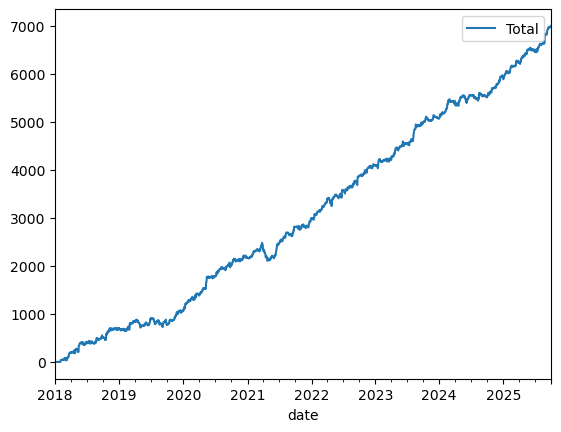

In [25]:
cutoff='2018-01-01'
signal_cap = [-2, 2]
chg_func = 'diff'
bullish = False
vol_win = 60
by_asset = False

signal_func = 'zscore'
param_rng = [10, 20, 1]
feature = 'dxy_index'

signal_df = pd.DataFrame(index=df_pxchg.index)

for asset in empiric_assets:
    #feature_ts = df_pxchg[asset].cumsum()
    #feature_ts = df[(asset+'c1', 'close')].dropna() #.pct_change() 
    if by_asset:
        asset_feature = f"{asset.lower()}_{feature}"
    else:
        asset_feature = feature
    #feature_ts = adf["US_IronOre"].dropna()
    #feature_ts = np.log(fut_data[asset].F1) - np.log(fut_data[asset].F2)
    #feature_ts = np.log(fut_data[asset].SPOT) - np.log(fut_data[asset].F1)    
    #feature_ts = fut_data[asset].F1.dropna() #.diff(5) #.pct_change()
    #feature_ts = np.log(fut_data[asset].F1)
    feature_ts =spot_df[asset_feature].dropna()
    signal_ts = calc_conv_signal(feature_ts, signal_func=signal_func, param_rng=param_rng, signal_cap=signal_cap, vol_win=vol_win) 
    #signal_ts = np.sign(feature_ts.diff(10)) #.pct_change()

    if not bullish:
        signal_ts = -signal_ts    
    
    signal_ts = signal_ts.reindex(index=cdates).ffill().reindex(index=df_pxchg.index)
    signal_df[asset] = signal_ts

#signal_df = xs_score(signal_df)
#signal_df = xs_demean(signal_df)
#signal_df = xs_sec_demean(signal_df)

holding = signal_df.div(vol_df).shift(1)
pnl_gross = holding.shift(1).multiply(df_pxchg)
pnl_net = pnl_gross - holding.diff().abs().multiply(2e-4)

met_list = []
for asset in pnl_net:
    sr_ts = calc_perf_by_tenors(pnl_gross[asset], tenors=pnl_tenors, metric='sharpe')
    met_list.append(sr_ts.to_frame(asset))
sr_df = pd.concat(met_list, axis=1)

pnl_per_trade = 100 * 100 * pnl_gross.mean(axis=0) / holding.diff().abs().mean()
turnover = 100 * holding.diff().abs().mean() / holding.abs().mean()
pnl_stats = pd.DataFrame({"pnl_per_trade": pnl_per_trade, "turnover": turnover})

port_pnl = pnl_net.sum(axis=1)
met_list = []
for metric in ['sharpe', 'std']:
    sr_ts = calc_perf_by_tenors(port_pnl, tenors=pnl_tenors, metric=metric)
    sr_ts.index=pnl_tenors
    met_list.append(sr_ts.to_frame(metric))

port_df = pd.concat(met_list, axis=1)

display(port_df.round(3))
display(sr_df.round(3))    
display(pnl_stats)

port_pnl.cumsum().to_frame("Total").plot()
plt.show()



Below is a list of strong signals that are used for portfolio construction

In [26]:
signal_store = {
    "pxmom_ts": [asset_list, 
                 ["pxmom", "zscore", [10, 20, 1], "", "", True, "", 20]],
    "pxmom_xsecdemean": [asset_list, 
                 ["pxmom", "zscore", [10, 20, 1], "", "", True, "", 20]],
    "futcarry_ts": [asset_list, 
                    ["futcarry", "ma", [1, 2, 1], "", "", True, "", 60]],
    "futcarry_xdemean": [asset_list, 
                    ["futcarry", "ma", [1, 2, 1], "", "", True, "", 60]],
    "phycarry_ts": [asset_list, 
                    ["phycarry", "ma", [1, 2, 1], "", "", True, "", 60]],
    "phycarry_xdemean": [asset_list, 
                    ["phycarry", "ma", [1, 2, 1], "", "", True, "", 60]],
    "dxymom": [us_assets, 
               ["dxy_index", "zscore", [20, 40, 2], "", "", False, "", 20]],
    "us10ymom": [asset_list, 
               ["us_10y_yield", "zscore", [60, 100, 2], "", "", False, "", 20]],
    "vixmom": [["US_Gold", "US_Silver"], 
               ["vix_level", "zscore", [10, 20, 1], "", "", True, "", 20]],
}


In [27]:
px_features = {}
for asset in asset_list:
    px_features[f"{asset}_pxmom"] = fut_data[asset].F1.dropna()
    px_features[f"{asset}_futcarry"] = np.log(fut_data[asset].F1) - np.log(fut_data[asset].F2)
    px_features[f"{asset}_phycarry"] = np.log(fut_data[asset].SPOT) - np.log(fut_data[asset].F1)
px_feature_df = pd.DataFrame(px_features)


In [28]:
# signal weight used for final portfolio

signal_weights = {
    "pxmom_ts": 0.065,
    "pxmom_xsecdemean": 0.125,
    #"futcarry_ts": 0,
    "futcarry_xdemean": 0.189,
    "phycarry_ts": 0.149,
    #"phycarry_xdemean": 0,
    "dxymom": 0.128,
    "vixmom": 1.024,
    "us10ymom": 0.09,
}

signal_dict = {}
signal_df = pd.DataFrame(0, columns=asset_list, index=cdates)

for signal_name in signal_weights:
    w = signal_weights[signal_name]
    signal_assets = signal_store[signal_name][0]
    feature, signal_func, param_rng, proc_func, chg_func, bullish, post_func, vol_win = signal_store[signal_name][1]

    if feature in ['pxmom', 'phycarry', 'futcarry']:        
        sig_df = pd.DataFrame(0, columns=asset_list, index=cdates)
        for asset in asset_list:
            asset_feature = f"{asset}_{feature}"
            if (asset not in signal_assets) or (asset_feature not in px_feature_df.columns):
                sig_df[asset] = np.nan
                continue
            signal_ts = signal_generator(px_feature_df, asset_feature, signal_func, param_rng, 
                                         proc_func, chg_func, bullish, signal_cap, 
                                         post_func, vol_win)
            sig_df[asset] = signal_ts
        sig_df = sig_df.reindex(index=cdates).ffill().reindex(index=df_pxchg.index)
        if "xdemean" in signal_name:
            sig_df = xs_demean(sig_df)
        elif "xsecdemean" in signal_name:
            sig_df = xs_sec_demean(sig_df)
        elif "xscore" in signal_name:
            sig_df = xs_score(sig_df)
        elif "xrank" in signal_name:
            sig_df = xs_rank(sig_df, 0.2)
    else:
        sig_ts = signal_generator(spot_df, feature, signal_func, param_rng,
                                  proc_func, chg_func, bullish, signal_cap,
                                  post_func, vol_win)
        sig_df = pd.DataFrame(columns=asset_list, index=cdates)
        for asset in asset_list:
            if asset in signal_assets:
                sig_df[asset] = sig_ts
            else:
                sig_df[asset] = np.nan
        sig_df = sig_df.reindex(index=cdates).ffill().reindex(index=df_pxchg.index).fillna(0)
    signal_dict[signal_name] = sig_df * w
    signal_df = signal_df + signal_dict[signal_name].reindex_like(signal_df).ffill().fillna(0)

signal_dict['combo'] = signal_df

pxmom_ts


pnl_per_trade    16.353776
turnover         61.114716
dtype: float64

,sharpe,std
6m,5.042495,0.882736
1y,3.096308,0.877676
2y,1.997404,0.929357
3y,2.157447,0.937803
4y,2.658052,0.920159
5y,2.528530,0.927085
6y,2.461542,0.931882
7y,2.200633,0.931886
8y,2.213317,0.918480
9y,2.213317,0.918480


pxmom_xsecdemean


pnl_per_trade    11.418344
turnover         67.288030
dtype: float64

...

pnl_per_trade     17.940155
turnover         140.478069
dtype: float64

,sharpe,std
6m,3.956020,1.872825
1y,2.505276,1.729149
2y,3.016821,1.736465
3y,3.130942,1.811184
4y,3.048374,1.840645
5y,3.254951,1.825902
6y,3.247210,1.816787
7y,3.032386,1.811181
8y,2.918740,1.776002
9y,2.918740,1.776002


combo


pnl_per_trade    38.921936
turnover         56.092744
dtype: float64

,sharpe,std
6m,10.026596,4.239582
1y,8.490851,4.444499
2y,7.588990,4.449793
3y,7.906490,4.355656
4y,7.903760,4.504590
5y,8.004796,4.474908
6y,8.256271,4.430411
7y,8.012843,4.402955
8y,7.883132,4.403680
9y,7.883132,4.403680


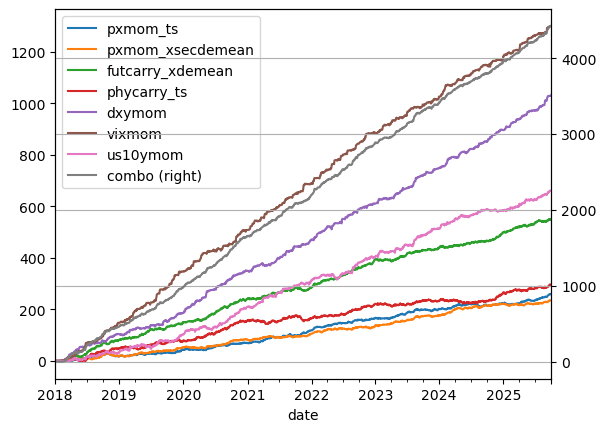

std:
pxmom_ts            0.918480
pxmom_xsecdemean    0.865235
futcarry_xdemean    1.405490
phycarry_ts         1.399020
dxymom              1.633924
vixmom              2.011220
us10ymom            1.776002
combo               4.403680
dtype: float64

corr:
                  pxmom_ts  pxmom_xsecdemean  futcarry_xdemean  phycarry_ts  \
pxmom_ts          1.000000          0.617861          0.078548    -0.023273   
pxmom_xsecdemean  0.617861          1.000000          0.075972    -0.001599   
futcarry_xdemean  0.078548          0.075972          1.000000     0.763053   
phycarry_ts      -0.023273         -0.001599          0.763053     1.000000   
dxymom            0.254217          0.243533         -0.016868     0.007708   
vixmom            0.133253          0.104848          0.010291    -0.005287   
us10ymom          0.167312          0.143554          0.001427     0.018119   

                    dxymom    vixmom  us10ymom  
pxmom_ts          0.254217  0.133253  0.167312  
pxmom_xsec

In [29]:
pnl_df = pd.DataFrame(index=df_pxchg.index)
for signal_name in signal_dict:
    print(signal_name)
    signal_df = signal_dict[signal_name]
    signal_df = signal_df.reindex_like(df_pxchg).ffill()
    holding = signal_df.div(vol_df).shift(1)
    pnl_gross = holding.shift(1).multiply(df_pxchg)
    pnl_per_trade = 100 * 100 * pnl_gross.mean(axis=0) / holding.diff().abs().mean()
    turnover = 100 * holding.diff().abs().mean() / holding.abs().mean()
    pnl_stats = pd.DataFrame({"pnl_per_trade": pnl_per_trade, "turnover": turnover})
    display(pnl_stats.mean())
    
    pnl_net = pnl_gross - holding.diff().abs().multiply(2e-4)
    strat_pnl = pnl_net.sum(axis=1)
    
    pnl_df[signal_name] = strat_pnl

    met_list = []
    for metric in ['sharpe', 'std']:
        sr_ts = calc_perf_by_tenors(strat_pnl, tenors=pnl_tenors, metric=metric)
        sr_ts.index=pnl_tenors
        met_list.append(sr_ts.to_frame(metric))

    perf_metric = pd.concat(met_list, axis=1)
    display(perf_metric)

    #strat_pnl.cumsum().plot(figsize=(8,6), title=signal_name)

pnl_df.cumsum().plot(secondary_y=["combo"])
plt.grid()
plt.show()

corr_cutoff = '2018-01-01'
print("std:\n%s\n" % pnl_df[corr_cutoff:].std(axis=0))

pnl_w_df = pnl_df.drop(columns=['combo']).resample('W').sum()
print("corr:\n%s\n" % pnl_w_df[corr_cutoff:].corr())

# pnl_df = pnl_df.fillna(0)
# pnl_df.sum(axis=1).cumsum().plot(title='combo')

This is the piece of portfolio optimization for the final weight (port_weight is on the unit strategy, final_weight is consider the std for individial strategy)

In [309]:
import pypfopt
from pypfopt import plotting
from pypfopt import risk_models
from pypfopt import EfficientFrontier
from pypfopt import expected_returns
#   
dpnl = pnl_df[[col for col in pnl_df.columns]]['2018-01-01':'2023-12-31']

if 'combo' in dpnl.columns:
    dpnl = dpnl.drop(columns=['combo'])
dpnl = dpnl.fillna(0)

strat_std = dpnl.std()

dpnl = dpnl/dpnl.std()

max_sharpe = False

if max_sharpe:
    mu = expected_returns.mean_historical_return(dpnl, returns_data=True, frequency=244, compounding=False)
else:
    mu = None

S = risk_models.CovarianceShrinkage(dpnl, returns_data=True, frequency=244).ledoit_wolf()
ef = EfficientFrontier(mu, S, weight_bounds= (0, 1)) 

fact_idx = {}
for fact in dpnl.columns:
    fact_idx[fact] = ef.tickers.index(fact)

#ef.add_constraint(lambda w: w[fact_idx['ryield_ema_ts']] + w[fact_idx['ryield_ema_xdemean']] >= 0.3)
#ef.add_constraint(lambda w: w[fact_idx['ryield_ema_ts']] + w[fact_idx['ryield_ema_xdemean']] <= 0.4)
#ef.add_constraint(lambda w: w[fact_idx['ryield_ema_ts']] + w[fact_idx['ryield_ema_xdemean']] >= 0.3)
# ef.add_constraint(lambda w: w[fact_idx['tsmom']] + w[fact_idx['macro2']] <= 0.24)

#ef = EfficientFrontier(mu, S, weight_bounds=(0,1))
if max_sharpe:
    port_weights = ef.max_sharpe()
else:
    port_weights = ef.min_volatility()

port_weights = pd.Series(port_weights)
print("port_weights=\n%s\n" % port_weights)
final_weights = port_weights.div(strat_std)
print("final_weights=\n%s\n" % final_weights)

port_weights=
pxmom_ts            0.091110
pxmom_xsecdemean    0.086352
futcarry_ts         0.000000
futcarry_xdemean    0.138695
phycarry_ts         0.137945
phycarry_xdemean    0.000000
dxymom              0.163581
vixmom              0.202121
us10ymom            0.180196
dtype: float64

final_weights=
pxmom_ts            0.006478
pxmom_xsecdemean    0.012490
futcarry_ts         0.000000
futcarry_xdemean    0.018873
phycarry_ts         0.014942
phycarry_xdemean    0.000000
dxymom              0.012814
vixmom              0.102444
us10ymom            0.009068
dtype: float64

